# Diversity Analysis on Par3 Generations (`translation_ref3`)

Applies six multidimensional diversity metrics and four text-level baselines to the Par3 translation generations: 
- Four open-weight instruction-tuned LLMs across 200 source paragraphs with up to five samples per model
- Par3 data contain 2–5 human translations per paragraph

**Metrics (from `metrics_lib`):**

| Metric | Function | Level |
|---|---|---|
| D_sem | `semantic_diversity` | group (same prompt, same source, multiple samples) |
| D_lex | `lexical_diversity` | group |
| D_syn | `syntactic_diversity` | group |
| D_disc | `discourse_diversity` | group |
| D_narr | `narrative_diversity` | group |
| D_style | `stylistic_diversity` | whole batch (normalized across all groups at once) |
| DIV | `diversity_score` | single text |
| Perplexity | `compute_perplexity` | single text |
| Coherence | `compute_coherence` | single text |
| Q*Text | `compute_qstar` | single text |

- "group": all samples for one source (model or human) and one prompt
- Group-level metrics need >= 2 texts per group (always true for LLMs and Humans)
- Data loading, quality filter (model: truncation / language drift, human: language drift + exact-duplicate) and the human 5-per-prompt cap all come from `common/data_prep.py`


In [2]:
# Load libraries
import pathlib
import pickle
import sys
import time
from itertools import combinations
from math import comb

import numpy as np
import pandas as pd

from scipy.stats import spearmanr
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

tqdm.pandas()


/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Repo root importable regardless of the kernel's working directory

def find_repo_root(start=None):
    start = pathlib.Path(start or pathlib.Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations' / 'translation_ref3').is_dir():
            return p
    raise FileNotFoundError("Could not locate the repo root (expected 'metrics/metrics_lib/' and "
                             "'data_generation/generations/translation_ref3/')")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Shared constants and data prep functions (common/constants.py, common/data_prep.py)
from common import MODEL_KEYS, MODEL_LABELS, MODEL_COLORS, MODEL_ORDER, GEN_ORDER, data_prep

# metrics_lib
from metrics.metrics_lib import (
    semantic_diversity, lexical_diversity, syntactic_diversity,
    discourse_diversity, narrative_diversity, stylistic_diversity,
)
from metrics.metrics_lib.baseline import (
    diversity_score, compute_perplexity, compute_coherence, compute_qstar,
    DEFAULT_MODEL_NAME, word_tokenize_simple,
)
from metrics.metrics_lib.pairwise import (
    distance_matrix, within_between, slices_from_lengths, style_distance_matrices,
    reference_control_splits, reference_control_splits_rowwise,
)

# Short tag for cache/output filenames tied to the scorer (e.g. 'opt-2.7b'), so switching
# DEFAULT_MODEL_NAME in metrics_lib.baseline can never silently reuse another model's cached scores
MODEL_TAG = DEFAULT_MODEL_NAME.split('/')[-1]

print(f'REPO_ROOT: {REPO_ROOT}')
print(f'Baseline scorer (Perplexity/Coherence): {DEFAULT_MODEL_NAME}')

REPO_ROOT: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity
Baseline scorer (Perplexity/Coherence): facebook/opt-2.7b


In [4]:
# Plotting parameters
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_theme(style='whitegrid')
FIG_DPI = 300

# Repo directories
DATA_DIR = REPO_ROOT / 'data_generation' / 'generations' / 'translation_ref3'  # or 'translation_ref4' -- identical layout
CACHE_DIR = REPO_ROOT / 'metrics' / '07_par3_diversity' / 'cache'
TABLES_DIR = REPO_ROOT / 'metrics' / '07_par3_diversity' / 'tables'
FIG_DIR = REPO_ROOT / 'figures' / 'par3_diversity'
for d in (CACHE_DIR, TABLES_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)


def save_fig(name):
    """tight_layout + save to FIG_DIR + show, for the current figure."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=FIG_DPI, bbox_inches='tight')
    plt.show()


METRIC_LABELS = {
    'D_sem': 'Semantic (Nomic cosine dist.)',
    'D_lex': 'Lexical (unigram Jaccard)',
    'D_syn': 'Syntactic (POS-bigram Jaccard)',
    'D_disc': 'Discourse (entity-grid JSD)',
    'D_narr': 'Narrative (sentiment-arc L2)',
    'D_style': 'Stylistic (11-feature)',
    'DIV': 'Diversity (n-gram repetition rate)',
    'Perplexity': f'Perplexity ({MODEL_TAG})',
    'Coherence': f'Coherence (log-prob | source, {MODEL_TAG})',
    'QStarText': 'Q*Text (0-100)',
}

GROUP_METRICS = ['D_sem', 'D_lex', 'D_syn', 'D_disc', 'D_narr', 'D_style']
BASELINE_METRICS = ['DIV', 'Perplexity', 'Coherence', 'QStarText']
ALL_METRICS = GROUP_METRICS + BASELINE_METRICS

print(f'DATA_DIR:   {DATA_DIR}')
print(f'CACHE_DIR:  {CACHE_DIR}')
print(f'TABLES_DIR: {TABLES_DIR}')
print(f'FIG_DIR:    {FIG_DIR}')

DATA_DIR:   /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/data_generation/generations/translation_ref3
CACHE_DIR:  /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/07_par3_diversity/cache
TABLES_DIR: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/07_par3_diversity/tables
FIG_DIR:    /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/figures/par3_diversity


## Load & Filter Data

In [5]:
# Canonical load + quality filter (model: truncation / language drift; human: language drift +
# exact-duplicate) from common/data_prep.py

_df = (data_prep.load_texts('translation_ref3', n_prompts=200)
       .drop(columns=['domain', 'prompt_id'])
       .rename(columns={'source': 'model_key', 'raw_prompt_id': 'prompt_id',
                        'story_id': 'sample_idx', 'text': 'translation', 'prompt': 'source_text'}))

_cols = ['model_key', 'model', 'prompt_id', 'sample_idx', 'source_text', 'translation']
df_gen = _df[_df.model_key != 'human'][_cols].reset_index(drop=True)
df_human = _df[_df.model_key == 'human'][_cols].reset_index(drop=True)

# Human groups keyed by raw prompt_id (used to build texts_by_group below)
human_translations_by_prompt = {pid: g['translation'].tolist() for pid, g in df_human.groupby('prompt_id')}

print(f'Generated translations: {len(df_gen)}  {df_gen.model.value_counts().reindex(GEN_ORDER).to_dict()}')
print(f'Human references: {len(df_human)} across {df_human.prompt_id.nunique()} paragraphs '
      f'(2-5 translators/paragraph)')

Generated translations: 3734  {'Gemma-2-9B': 936, 'Llama-3.1-8B': 991, 'Mistral-7B-v0.3': 973, 'Qwen2.5-7B': 834}
Human references: 669 across 200 paragraphs (2-5 translators/paragraph)


In [6]:
# Fingerprint the exact loaded text rows so a corpus change forces fresh caches everywhere
DATA_FINGERPRINT = data_prep.dataframe_fingerprint(
    _df, cols=['model_key', 'prompt_id', 'sample_idx', 'translation'])
print(f'Dataset fingerprint: {DATA_FINGERPRINT}')

Dataset fingerprint: ad763612a3dfe4aa


In [7]:
# Model quality filter already applied by common/data_prep.py

group_sizes = df_gen.groupby(['model', 'prompt_id']).size()
print('Translations per model:')
print(df_gen['model'].value_counts().reindex(GEN_ORDER))
print('\nGroup-size distribution (samples per model x paragraph):')
print(group_sizes.value_counts().sort_index())
print(f'Model groups with < 2 samples (cannot compute group diversity): {(group_sizes < 2).sum()}')

Translations per model:
model
Gemma-2-9B         936
Llama-3.1-8B       991
Mistral-7B-v0.3    973
Qwen2.5-7B         834
Name: count, dtype: int64

Group-size distribution (samples per model x paragraph):
1     13
2     15
3     27
4     65
5    670
Name: count, dtype: int64
Model groups with < 2 samples (cannot compute group diversity): 13


## Build Paragraph Groups

A group is `(source, prompt_id)` -> list of translation texts, where source is one of the 4 LLMs or `human`


In [8]:
# group_id = 'source/prompt_id' -> list of translation texts (only groups with >= 2 samples are usable)
texts_by_group = {}
for (model_key, prompt_id), g in df_gen.groupby(['model_key', 'prompt_id']):
    if len(g) >= 2:
        texts_by_group[f'{model_key}/{prompt_id}'] = g['translation'].tolist()

# Human groups: only paragraphs with >= 2 distinct human translators in the source corpus
for prompt_id, translations in human_translations_by_prompt.items():
    if len(translations) >= 2:
        texts_by_group[f'human/{prompt_id}'] = translations

group_ids = list(texts_by_group.keys())

# group_id -> (model_key, prompt_id)
group_key = {gid: tuple(gid.split('/', 1)) for gid in group_ids}

n_human_groups = sum(1 for gid in group_ids if gid.startswith('human/'))
print(f'{len(group_ids)} usable groups (source x paragraph) with >= 2 samples, of which {n_human_groups} are human')
print(f'Total texts across groups: {sum(len(v) for v in texts_by_group.values())}')

977 usable groups (source x paragraph) with >= 2 samples, of which 200 are human
Total texts across groups: 4390


## Compute Metrics
### Compute the Group-Level Metrics

- One `metrics_lib` call per group for `D_sem`, `D_lex`, `D_syn`, `D_disc`, `D_narr`
- Each is cached to its own CSV in this folder, incrementally (only groups missing from the cache are computed)

In [9]:
def compute_group_metric(metric_name, func, cache_name, **kwargs):
    """Run `func(texts, **kwargs)` for every group not already cached, merge with whatever's
    cached, save and return a DataFrame indexed by group_id with columns
    [model_key, prompt_id, <metric_name>] for exactly `group_ids`."""

    # Check cache and load existing results if available
    cache_path = CACHE_DIR / cache_name
    if cache_path.exists():
        cached = pd.read_csv(cache_path).set_index('group_id')
    else:
        cached = pd.DataFrame(columns=['model_key', 'prompt_id', metric_name]).set_index(
            pd.Index([], name='group_id'))

    # Identify which groups are missing from the cache
    missing = [gid for gid in group_ids if gid not in cached.index]
    if not missing:
        print(f'{metric_name}: all {len(group_ids)} groups already cached ({cache_path.name})')
        return cached.loc[group_ids]

    # Compute the metric for the missing groups
    rows = []
    n_failed = 0
    t0 = time.time()
    for gid in tqdm(missing, desc=metric_name):
        model_key, prompt_id = group_key[gid]
        try:
            value = func(texts_by_group[gid], **kwargs)
        except Exception:
            value = np.nan
            n_failed += 1
        rows.append({'group_id': gid, 'model_key': model_key, 'prompt_id': prompt_id, metric_name: value})
    dt = time.time() - t0

    # Merge new results with cached results, remove duplicates (keep last) and save to cache
    new_df = pd.DataFrame(rows).set_index('group_id')
    result = pd.concat([cached, new_df])
    result = result[~result.index.duplicated(keep='last')]
    result.to_csv(cache_path)

    print(f'{metric_name}: computed {len(new_df)} new groups in {dt:.0f}s ({n_failed} failed -> NaN); '
          f'{len(result)} total cached, saved to {cache_path.name}')
    return result.loc[group_ids]

In [10]:
# D_sem: mean pairwise cosine distance of Nomic Embed Text v1.5 embeddings
df_d_sem = compute_group_metric('D_sem', semantic_diversity, f'cache_d_sem_{DATA_FINGERPRINT}.csv')
df_d_sem['D_sem'].describe().round(4)

D_sem: all 977 groups already cached (cache_d_sem_ad763612a3dfe4aa.csv)


count    977.0000
mean       0.0415
std        0.0386
min        0.0026
25%        0.0168
50%        0.0306
75%        0.0522
max        0.2816
Name: D_sem, dtype: float64

In [11]:
df_d_lex = compute_group_metric('D_lex', lexical_diversity, f'cache_d_lex_{DATA_FINGERPRINT}.csv')
df_d_lex['D_lex'].describe().round(4)

D_lex: all 977 groups already cached (cache_d_lex_ad763612a3dfe4aa.csv)


count    977.0000
mean       0.5692
std        0.1434
min        0.2665
25%        0.4504
50%        0.5639
75%        0.6779
max        0.9078
Name: D_lex, dtype: float64

In [12]:
df_d_syn = compute_group_metric('D_syn', syntactic_diversity, f'cache_d_syn_{DATA_FINGERPRINT}.csv')
df_d_syn['D_syn'].describe().round(4)

D_syn: all 977 groups already cached (cache_d_syn_ad763612a3dfe4aa.csv)


count    977.0000
mean       0.2554
std        0.0847
min        0.0685
25%        0.1901
50%        0.2461
75%        0.3133
max        0.5111
Name: D_syn, dtype: float64

In [13]:
df_d_disc = compute_group_metric('D_disc', discourse_diversity, f'cache_d_disc_{DATA_FINGERPRINT}.csv')
df_d_disc['D_disc'].describe().round(4)

D_disc: all 977 groups already cached (cache_d_disc_ad763612a3dfe4aa.csv)


count    966.0000
mean       0.0185
std        0.0210
min       -0.0000
25%        0.0059
50%        0.0126
75%        0.0228
max        0.2151
Name: D_disc, dtype: float64

In [14]:
# D_narr: transformer sentiment arcs (siebert/sentiment-roberta-large-english, CPU)
df_d_narr = compute_group_metric('D_narr', narrative_diversity, f'cache_d_narr_{DATA_FINGERPRINT}.csv')
df_d_narr['D_narr'].describe().round(4)

D_narr: all 977 groups already cached (cache_d_narr_ad763612a3dfe4aa.csv)


count    955.0000
mean       2.1418
std        0.8350
min        0.0055
25%        1.5820
50%        2.0974
75%        2.6690
max        4.9616
Name: D_narr, dtype: float64

### D_style: Stylistic Diversity (Whole-Batch Normalization)

`stylistic_diversity()` must be called once with every group at once (its two raw components are winsorized + min-max normalized across the whole batch before being combined)

In [15]:
# The cache is only valid if it covers exactly this set of groups (whole-batch normalization)
cache_path = CACHE_DIR / f'cache_d_style_{DATA_FINGERPRINT}.csv'
df_d_style = pd.read_csv(cache_path).set_index('group_id') if cache_path.exists() else None
if df_d_style is not None and set(df_d_style.index) != set(group_ids):
    df_d_style = None

# Compute D_style: mean pairwise distance in 11-dimensional stylistic feature space
if df_d_style is None:
    t0 = time.time()

    d_style_scores = stylistic_diversity(texts_by_group)
    dt = time.time() - t0

    # Save to cache with group_id, model_key, prompt_id, D_style columns
    rows = [{'group_id': gid, 'model_key': group_key[gid][0], 'prompt_id': group_key[gid][1], 'D_style': v}
            for gid, v in d_style_scores.items()]
    df_d_style = pd.DataFrame(rows).set_index('group_id')
    df_d_style.to_csv(cache_path)
    print(f'D_style: computed {len(df_d_style)} groups in {dt:.0f}s, saved to {cache_path.name}')
else:
    print(f'D_style: loaded from cache ({cache_path.name})')

df_d_style['D_style'].describe().round(4)

D_style: loaded from cache (cache_d_style_ad763612a3dfe4aa.csv)


count    977.0000
mean       0.3912
std        0.2253
min        0.0241
25%        0.2211
50%        0.3411
75%        0.5065
max        1.0000
Name: D_style, dtype: float64

### Baseline Metrics: Diversity, Perplexity, Coherence, Q*Text

`metrics_lib.baseline` plus the n-gram `diversity_score()`

- **Diversity (`DIV`)**: `diversity_score()` product of unique/total 2-,3-,4-gram ratios, single-text
- **Perplexity**: self-predictability of a translation alone, under OPT-2.7B
- **Coherence**: mean log-probability of a translation's tokens conditioned on its source-language paragraph under OPT-2.7B
- **Q\*Text**: weighted, Gaussian-penalized combination of the three above (fitted parameters from the paper), normalized across every text in this dataset


In [16]:
# One row per text (model samples + human references); df_gen and df_human share the same columns
df_story = pd.concat([df_gen, df_human], ignore_index=True)

df_story['DIV'] = df_story['translation'].progress_apply(diversity_score)
df_story.to_csv(CACHE_DIR / 'cache_div.csv', index=False)

df_story.groupby('model')['DIV'].describe().reindex(MODEL_ORDER).round(4)

100%|██████████| 4403/4403 [00:00<00:00, 10810.80it/s]


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Human,669.0,0.9340,0.0449,0.6492,0.9091,0.9422,0.9667,1.0
Gemma-2-9B,936.0,0.9321,0.0457,0.6487,0.9112,0.9394,0.9642,1.0
Llama-3.1-8B,991.0,0.9228,0.0525,0.3911,0.8993,0.9328,0.9604,1.0
Mistral-7B-v0.3,973.0,0.8656,0.2054,0.0104,0.8918,0.9282,0.9574,1.0
Qwen2.5-7B,834.0,0.9303,0.0520,0.3896,0.9106,0.9393,0.9641,1.0


In [17]:
def compute_story_metric(metric_name, cache_name, compute_fn):
    """Incrementally cached per (model_key, prompt_id, sample_idx). compute_fn(row) -> value."""

    # Check cache and load existing results if available
    cache_path = CACHE_DIR / cache_name
    if cache_path.exists():
        cache_df = pd.read_csv(cache_path)
        cache = {(r.model_key, r.prompt_id, r.sample_idx): getattr(r, metric_name)
                 for r in cache_df.itertuples()}
    else:
        cache = {}

    # Compute the metric for each text, skipping those already cached
    values = []
    n_new = 0
    t0 = time.time()
    for row in tqdm(df_story.itertuples(), total=len(df_story), desc=metric_name):
        key = (row.model_key, row.prompt_id, row.sample_idx)
        if key not in cache:
            try:
                cache[key] = compute_fn(row)
            except Exception:
                cache[key] = np.nan
            n_new += 1
        values.append(cache[key])
    dt = time.time() - t0

    out_rows = [{'model_key': k[0], 'prompt_id': k[1], 'sample_idx': k[2], metric_name: v}
                for k, v in cache.items()]
    pd.DataFrame(out_rows).to_csv(cache_path, index=False)
    print(f'{metric_name}: computed {n_new} new (of {len(df_story)} total) in {dt:.0f}s, saved to {cache_path.name}')
    return values


# Cache filenames carry MODEL_TAG and DATA_FINGERPRINT so a scorer change or a corpus change
# always recomputes fresh instead of silently reusing another model's/corpus's cached scores
df_story['Perplexity'] = compute_story_metric(
    'Perplexity', f'cache_perplexity_{MODEL_TAG}_{DATA_FINGERPRINT}.csv', lambda row: compute_perplexity(row.translation))
df_story['Coherence'] = compute_story_metric(
    'Coherence', f'cache_coherence_{MODEL_TAG}_{DATA_FINGERPRINT}.csv', lambda row: compute_coherence(row.source_text, row.translation))

df_story[['DIV', 'Perplexity', 'Coherence']].describe().round(4)

Perplexity: 100%|██████████| 4403/4403 [00:00<00:00, 244082.43it/s]


Perplexity: computed 0 new (of 4403 total) in 0s, saved to cache_perplexity_opt-2.7b_ad763612a3dfe4aa.csv


Coherence: 100%|██████████| 4403/4403 [00:00<00:00, 233851.93it/s]

Coherence: computed 0 new (of 4403 total) in 0s, saved to cache_coherence_opt-2.7b_ad763612a3dfe4aa.csv


,DIV,Perplexity,Coherence
count,4403.0000,4403.0000,4403.0000
mean,0.9152,24.2966,-2.8595
std,0.1091,9.0345,0.4486
min,0.0104,5.8990,-4.6133
25%,0.9038,18.1653,-3.1719
50%,0.9361,22.5742,-2.8926
75%,0.9623,28.6038,-2.5605
max,1.0000,97.7536,-0.8013


In [18]:
# Q*Text needs perplexity/coherence/diversity normalized against each other's min/max across every text being compared 

valid = df_story[['Perplexity', 'Coherence', 'DIV']].notna().all(axis=1)
df_story.loc[valid, 'QStarText'] = compute_qstar(
    df_story.loc[valid, 'Perplexity'], df_story.loc[valid, 'Coherence'], df_story.loc[valid, 'DIV'])

print(f'Q*Text computed for {valid.sum()} of {len(df_story)} texts '
      f'({(~valid).sum()} skipped: missing Perplexity/Coherence/DIV)')

df_story.groupby('model')[BASELINE_METRICS].mean().reindex(MODEL_ORDER).round(4)

Q*Text computed for 4403 of 4403 texts (0 skipped: missing Perplexity/Coherence/DIV)


,DIV,Perplexity,Coherence,QStarText
model,,,,
Human,0.9340,20.6597,-2.7921,75.5149
Gemma-2-9B,0.9321,23.6019,-2.8175,75.5377
Llama-3.1-8B,0.9228,24.8717,-2.8817,75.2474
Mistral-7B-v0.3,0.8656,27.0623,-2.9517,70.1396
Qwen2.5-7B,0.9303,24.0839,-2.8267,75.4625


### Combine the Six Diversity Metrics

One row per `(source, prompt_id)` group. The text-level baselines remain in the separate paragraph-aggregated table `df_story_prompt`.


In [19]:
# Merge all group-level metrics into a single DataFrame for analysis and plotting
df_metrics = df_d_sem[['model_key', 'prompt_id', 'D_sem']].copy()
for other in [df_d_lex, df_d_syn, df_d_disc, df_d_narr, df_d_style]:
    df_metrics = df_metrics.join(other[[other.columns[-1]]])

df_metrics['model'] = df_metrics['model_key'].map(MODEL_LABELS)
df_metrics = df_metrics[['model_key', 'model', 'prompt_id'] + GROUP_METRICS]

# One observation per source and paragraph
df_story_prompt = (
    df_story.groupby(['model_key', 'model', 'prompt_id'], as_index=False)[BASELINE_METRICS]
    .mean()
)

print(f'df_metrics: {df_metrics.shape[0]} source-paragraph groups')
print(f'df_story_prompt: {df_story_prompt.shape[0]} source-paragraph baseline rows')
print(df_metrics['model'].value_counts().reindex(MODEL_ORDER))
print('\nMissing values per diversity metric:')
print(df_metrics[GROUP_METRICS].isna().sum())
df_metrics.head()


df_metrics: 977 source-paragraph groups
df_story_prompt: 990 source-paragraph baseline rows
model
Human              200
Gemma-2-9B         196
Llama-3.1-8B       200
Mistral-7B-v0.3    200
Qwen2.5-7B         181
Name: count, dtype: int64

Missing values per diversity metric:
D_sem       0
D_lex       0
D_syn       0
D_disc     11
D_narr     22
D_style     0
dtype: int64


,model_key,model,prompt_id,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
group_id,,,,,,,,,
gemma/par3_0000,gemma,Gemma-2-9B,par3_0000,0.030777,0.403143,0.090122,0.006547,1.613084,0.166492
gemma/par3_0001,gemma,Gemma-2-9B,par3_0001,0.013419,0.268566,0.068483,0.002762,0.694487,0.204527
gemma/par3_0002,gemma,Gemma-2-9B,par3_0002,0.028964,0.334212,0.176306,0.000000,2.002327,0.137587
gemma/par3_0003,gemma,Gemma-2-9B,par3_0003,0.022753,0.324731,0.151976,0.019792,0.661850,0.202789
gemma/par3_0004,gemma,Gemma-2-9B,par3_0004,0.018341,0.652975,0.368334,0.069798,1.926573,0.409821


## Descriptive Statistics by Model

In [20]:
# Mean and number of source paragraphs per (model, metric): group metrics from df_metrics,
# baselines from their paragraph-level means in df_story_prompt
summary_table = pd.concat([
    df_metrics.groupby('model')[GROUP_METRICS].mean(),
    df_story_prompt.groupby('model')[BASELINE_METRICS].mean(),
], axis=1).reindex(MODEL_ORDER)[ALL_METRICS]
n_table = pd.concat([
    df_metrics.groupby('model')[GROUP_METRICS].count(),
    df_story_prompt.groupby('model')[BASELINE_METRICS].count(),
], axis=1).reindex(MODEL_ORDER)[ALL_METRICS]

print('Number of source paragraphs per cell:')
display(n_table)
summary_table.round(4)

Number of source paragraphs per cell:


,D_sem,D_lex,D_syn,D_disc,D_narr,D_style,DIV,Perplexity,Coherence,QStarText
model,,,,,,,,,,
Human,200,200,200,199,186,200,200,200,200,200
Gemma-2-9B,196,196,196,193,194,196,199,199,199,199
Llama-3.1-8B,200,200,200,198,198,200,200,200,200,200
Mistral-7B-v0.3,200,200,200,197,199,200,200,200,200,200
Qwen2.5-7B,181,181,181,179,178,181,191,191,191,191


,D_sem,D_lex,D_syn,D_disc,D_narr,D_style,DIV,Perplexity,Coherence,QStarText
model,,,,,,,,,,
Human,0.0739,0.7221,0.3284,0.0278,2.7289,0.6475,0.9355,20.8776,-2.7972,75.5335
Gemma-2-9B,0.0259,0.4788,0.2151,0.0128,1.9241,0.2750,0.9324,23.5047,-2.8288,75.5323
Llama-3.1-8B,0.0386,0.5809,0.2599,0.0178,2.0818,0.3827,0.9227,24.8667,-2.8828,75.2328
Mistral-7B-v0.3,0.0382,0.5226,0.2364,0.0182,1.9919,0.3324,0.8628,27.0248,-2.9555,69.9006
Qwen2.5-7B,0.0296,0.5366,0.2344,0.0155,2.0001,0.3083,0.9280,24.0267,-2.8546,75.3692


## Distributions by Model

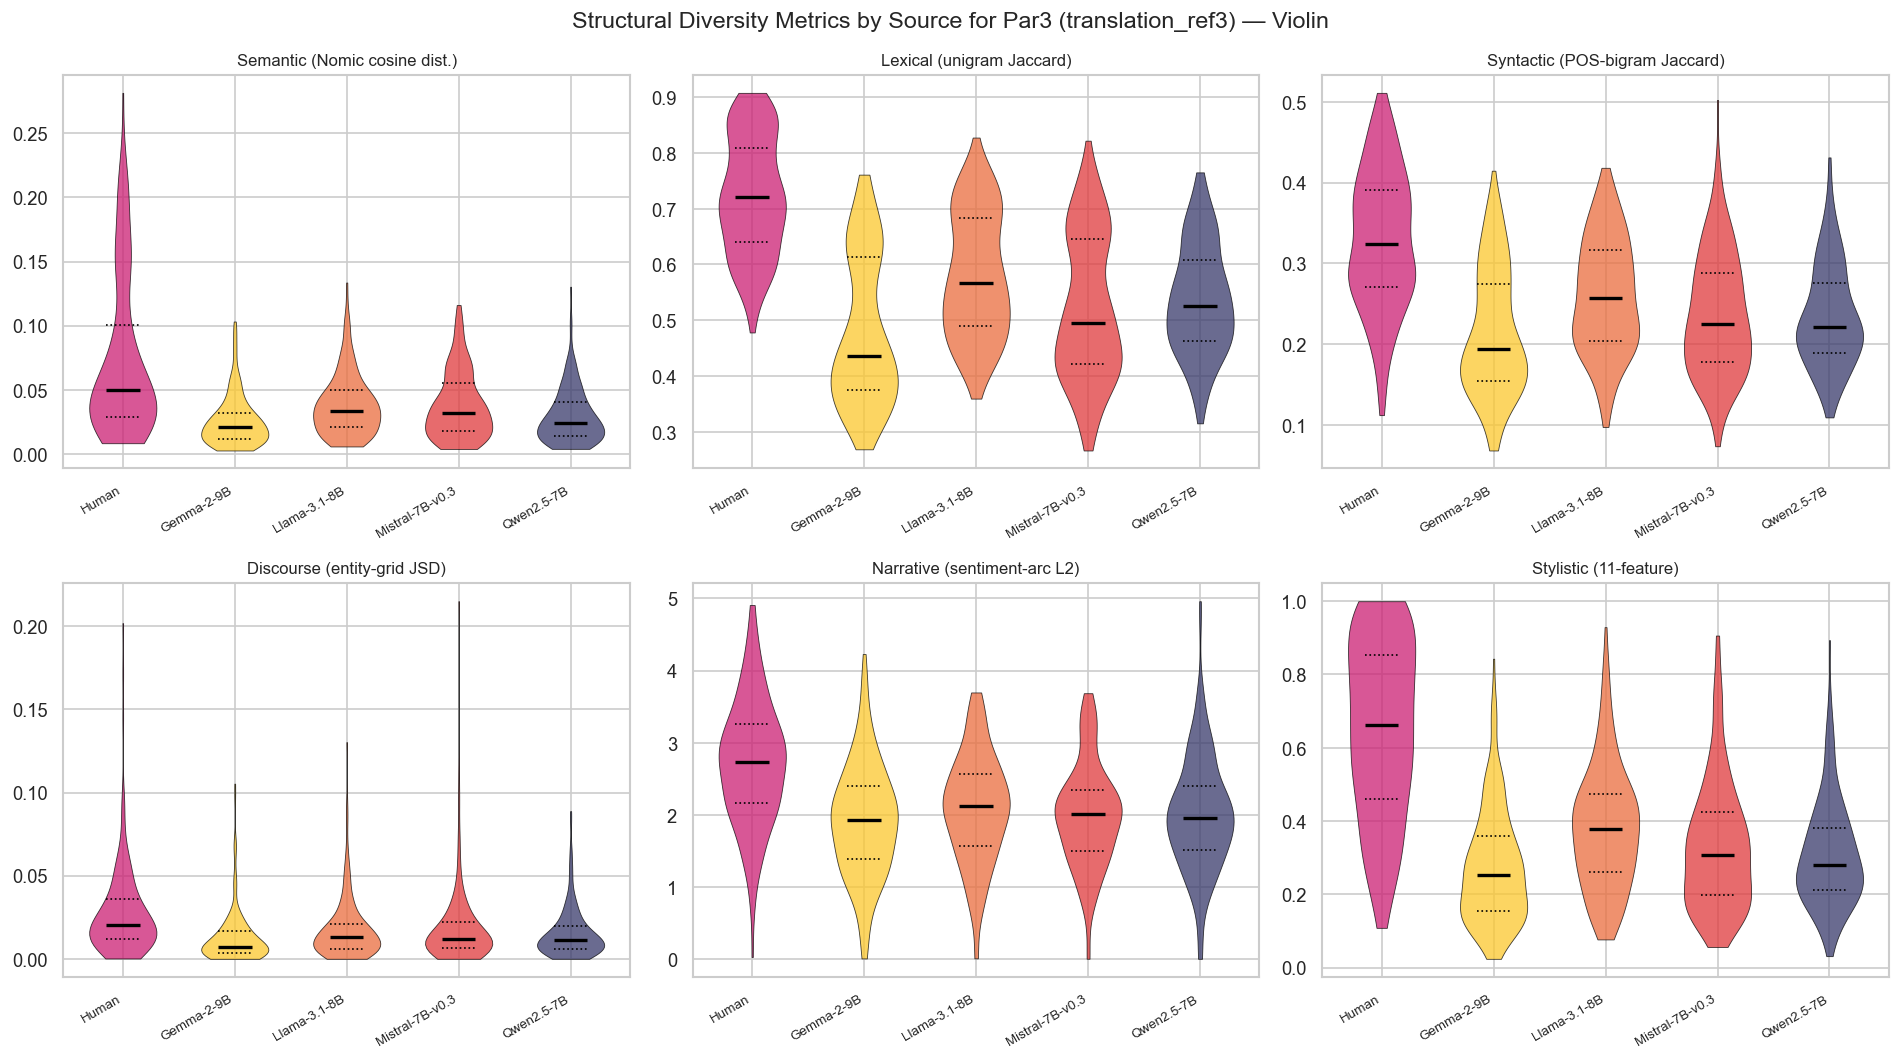

In [21]:
def styled_violin(ax, data, labels, colors, alphas=None, **tick_kw):
    """Matplotlib violinplot with colored bodies, a solid black median line and dotted black
    Q1/Q3 lines -- shows distribution shape, skew and multimodality. `tick_kw` is passed to
    `ax.set_xticklabels` (e.g. rotation, ha, fontsize)."""
    alphas = alphas if alphas is not None else [0.75] * len(data)
    positions = range(1, len(data) + 1)
    parts = ax.violinplot(data, positions=positions, widths=0.6, showmedians=True,
                           showextrema=False, quantiles=[[0.25, 0.75]] * len(data))
    for pc, c, a in zip(parts['bodies'], colors, alphas):
        pc.set_facecolor(c)
        pc.set_alpha(a)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    parts['cquantiles'].set_color('black')
    parts['cquantiles'].set_linewidth(1)
    parts['cquantiles'].set_linestyle(':')
    ax.set_xticks(list(positions))
    ax.set_xticklabels(labels, **tick_kw)
    return parts


# One value per source and paragraph (one point per (model, prompt_id), not per individual text)
MODEL_ORDER_COLORS = [MODEL_COLORS[m] for m in MODEL_ORDER]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, metric in zip(axes.flat, GROUP_METRICS):
    data = [df_metrics.loc[df_metrics.model == m, metric].dropna().values for m in MODEL_ORDER]
    styled_violin(ax, data, MODEL_ORDER, MODEL_ORDER_COLORS, rotation=30, ha='right', fontsize=8)
    ax.set_title(METRIC_LABELS[metric], fontsize=10)

fig.suptitle('Structural Diversity Metrics by Source for Par3 (translation_ref3) \u2014 Violin', fontsize=14)
save_fig('diversity_metrics_by_model_violin.png')

## Metric Intercorrelations

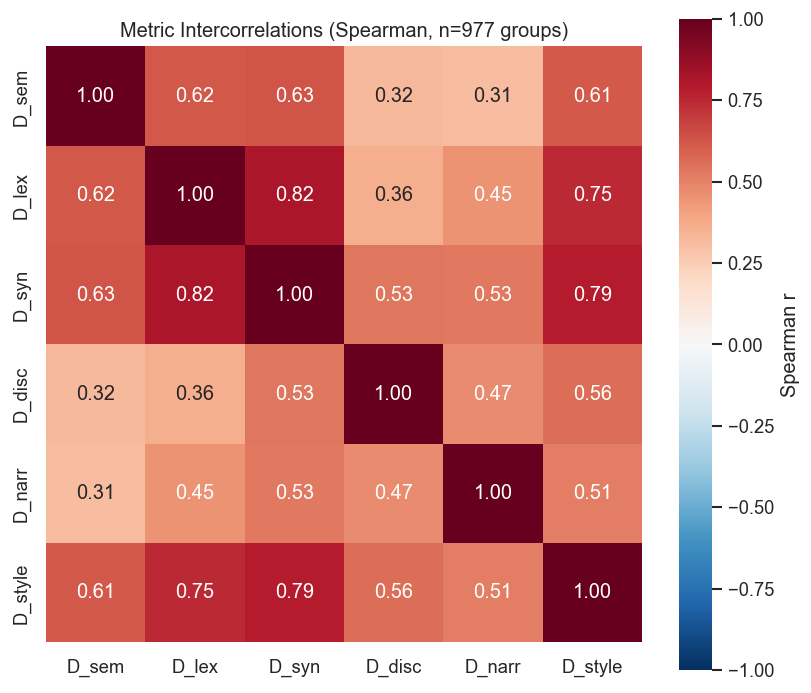

,D_sem,D_lex,D_syn,D_disc,D_narr,D_style
D_sem,1.000,0.622,0.628,0.323,0.307,0.612
D_lex,0.622,1.000,0.817,0.362,0.448,0.748
D_syn,0.628,0.817,1.000,0.534,0.530,0.789
D_disc,0.323,0.362,0.534,1.000,0.473,0.560
D_narr,0.307,0.448,0.530,0.473,1.000,0.512
D_style,0.612,0.748,0.789,0.560,0.512,1.000


In [22]:
corr_matrix = df_metrics[GROUP_METRICS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Spearman r'}, ax=ax)
ax.set_title('Metric Intercorrelations (Spearman, n=%d groups)' % len(df_metrics))
save_fig('metric_intercorrelations.png')

corr_matrix.round(3)

## Baseline Metrics: Prompt-Level Distributions


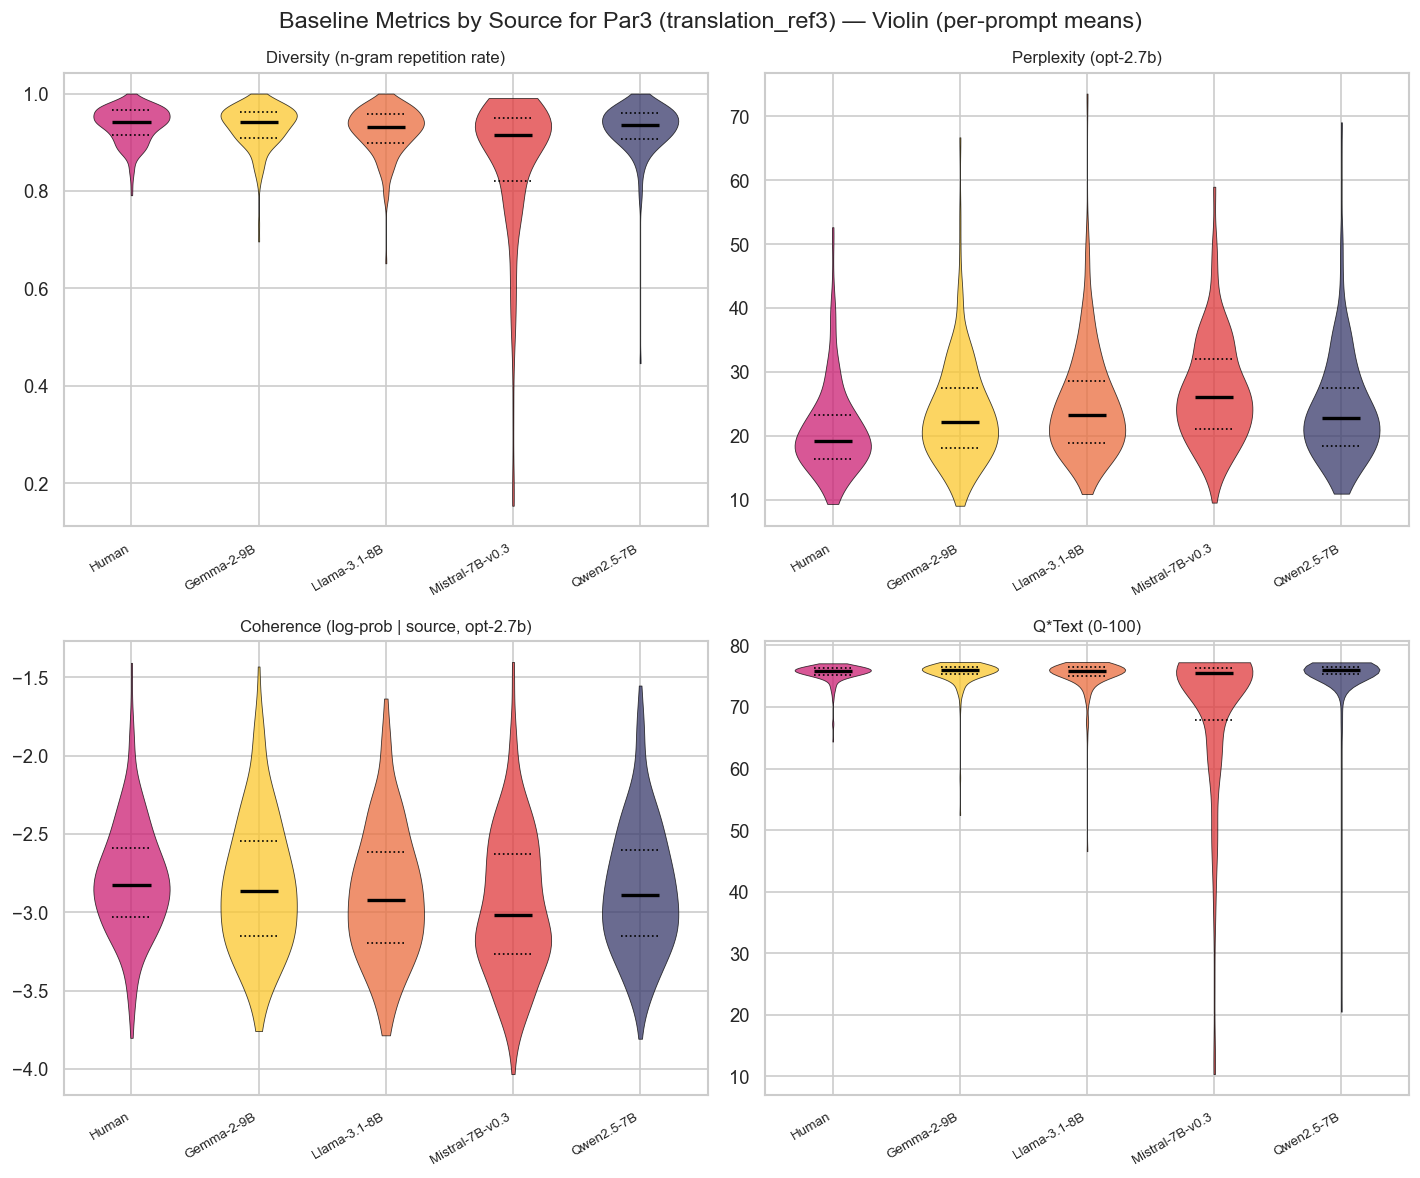

In [23]:
# One value per source and paragraph; defined when the analysis table was assembled.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, metric in zip(axes.flat, BASELINE_METRICS):
    data = [df_story_prompt.loc[df_story_prompt.model == m, metric].dropna().values for m in MODEL_ORDER]
    styled_violin(ax, data, MODEL_ORDER, MODEL_ORDER_COLORS, rotation=30, ha='right', fontsize=8)
    ax.set_title(METRIC_LABELS[metric], fontsize=10)

fig.suptitle('Baseline Metrics by Source for Par3 (translation_ref3) \u2014 Violin (per-prompt means)', fontsize=14)
save_fig('baseline_metrics_by_model_violin.png')

## Export Results

In [24]:
out_path = TABLES_DIR / 'par3_diversity_results.csv'
df_metrics.to_csv(out_path, index=False)
print(f'Exported group-level results: {out_path} ({len(df_metrics)} rows)')

summary_out_path = TABLES_DIR / 'par3_diversity_summary.csv'
summary_table.to_csv(summary_out_path)
print(f'Exported per-model summary: {summary_out_path}')

# Model-tagged: this file's Perplexity/Coherence/QStarText columns are scorer-dependent
df_story.to_csv(CACHE_DIR / f'cache_baseline_metrics_{MODEL_TAG}_{DATA_FINGERPRINT}.csv', index=False)
baseline_summary = df_story_prompt.groupby('model')[BASELINE_METRICS].agg(['mean', 'std']).reindex(MODEL_ORDER)
baseline_summary.to_csv(TABLES_DIR / f'par3_baseline_summary_{MODEL_TAG}_{DATA_FINGERPRINT}.csv')
print(f'Exported baseline metrics ({len(df_story)} texts) and per-model summary')


Exported group-level results: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/07_par3_diversity/tables/par3_diversity_results.csv (977 rows)
Exported per-model summary: /Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/metrics/07_par3_diversity/tables/par3_diversity_summary.csv
Exported baseline metrics (4403 texts) and per-model summary


## Pairwise Distance Matrices for Human-Relative Analyses

For every prompt and metric build one distance matrix over all human and model texts. The matrices are reused by the matched Reference/Control score, the full-distribution credal-set view and the energy-distance analysis.


In [25]:
MATRIX_CACHE = CACHE_DIR / f'cache_pairing_matrices_{DATA_FINGERPRINT}.pkl'

# The current pairwise semantic implementation uses the same Nomic task prefix,
# normalize_embeddings=True and batch_size=8 as semantic_diversity()
SEMANTIC_MATRIX_SCHEMA = 'nomic_clustering_normalized_batch8_v2'
SEMANTIC_SCHEMA_KEY = ('__meta__', 'semantic_matrix_schema')

# The minimum number of human references required for a prompt to be included in the human-relative analyses
MIN_HUMAN_REF = 3

DIST_METRICS = ['D_sem', 'D_lex', 'D_syn', 'D_disc', 'D_narr']
PAIRING_METRICS = DIST_METRICS + ['D_style']
MODEL_SOURCES = MODEL_KEYS                # ['gemma', 'llama', 'mistral', 'qwen'], labels = GEN_ORDER
SOURCE_ORDER = ['human', *MODEL_SOURCES]

# Create a dictionary mapping (model_key, prompt_id) to a list of translated texts
model_texts = {
    (model_key, prompt_id): group['translation'].tolist()
    for (model_key, prompt_id), group in df_gen.groupby(['model_key', 'prompt_id'])
}

# prompt_id -> [(source, texts), ...] with the human segment first, followed by every model
# with >= 2 samples; only prompts with >= 2 human references and >= 1 such model are kept
segments_by_prompt = {}
for prompt_id, human_texts in human_translations_by_prompt.items():

    # Only keep prompts with >= 2 human references and >= 1 model with >= 2 samples
    if len(human_texts) < 2:
        continue

    # Build the list of segments for this prompt: human first, then each model with >= 2 samples
    segments = [('human', human_texts)]
    for model_key in MODEL_SOURCES:
        model_samples = model_texts.get((model_key, prompt_id), [])

        # Only keep models with >= 2 samples for this prompt
        if len(model_samples) >= 2:
            segments.append((model_key, model_samples))

    # Only keep prompts with >= 2 segments (human + at least one model)
    if len(segments) >= 2:
        segments_by_prompt[prompt_id] = segments

pairing_prompts = sorted(segments_by_prompt)

# Per-prompt layout shared by every matrix below: flattened texts [human | model_1 | ...] and
# the (start, stop) row slice of each source in that order
texts_by_prompt = {pid: [t for _, seg in segments_by_prompt[pid] for t in seg] for pid in pairing_prompts}
slices_by_prompt = {pid: slices_from_lengths([(s, len(t)) for s, t in segments_by_prompt[pid]])
                    for pid in pairing_prompts}

# Prompts with enough human references for the human-relative analyses
human_ref_counts = pd.Series({pid: len(segments_by_prompt[pid][0][1]) for pid in pairing_prompts},
                             name='n_human_refs')
ref_prompts = human_ref_counts.index[human_ref_counts >= MIN_HUMAN_REF].tolist()

print(f'{len(pairing_prompts)} prompts with a usable matrix; '
      f'{len(ref_prompts)} with >= {MIN_HUMAN_REF} human refs')
print('Human references per prompt:', human_ref_counts.value_counts().sort_index().to_dict())
print('Model sources present per prompt:',
      pd.Series([len(segments_by_prompt[pid]) - 1 for pid in pairing_prompts])
      .value_counts().sort_index().to_dict())

200 prompts with a usable matrix; 200 with >= 3 human refs
Human references per prompt: {3: 132, 4: 67, 5: 1}
Model sources present per prompt: {2: 2, 3: 19, 4: 179}


In [26]:
# One distance matrix per (metric, prompt) over [humans | model_1 | ...], cached across runs
if MATRIX_CACHE.exists():
    with open(MATRIX_CACHE, 'rb') as handle:
        pairing_matrices = pickle.load(handle)
else:
    pairing_matrices = {}


def save_matrix_cache():
    with open(MATRIX_CACHE, 'wb') as handle:
        pickle.dump(pairing_matrices, handle)


# Invalidate any cached semantic matrices that were computed with a different schema than the current one
if pairing_matrices.get(SEMANTIC_SCHEMA_KEY) != SEMANTIC_MATRIX_SCHEMA:

    # Remove any cached semantic matrices that were computed with a different schema
    stale_semantic = [
        key for key in pairing_matrices
        if isinstance(key, tuple) and len(key) == 2 and key[0] == 'D_sem'
    ]

    # Remove stale semantic matrices
    for key in stale_semantic:
        del pairing_matrices[key]

    # Update the schema key to the current schema
    pairing_matrices[SEMANTIC_SCHEMA_KEY] = SEMANTIC_MATRIX_SCHEMA
    print(f'Invalidated {len(stale_semantic)} stale semantic matrices.')


# Compute missing matrices; a cached None is a failed computation, not a completed entry: retry it
matrix_errors = []
for metric in DIST_METRICS:

    # Identify prompts that are missing a cached matrix for this metric
    pending = [pid for pid in pairing_prompts if pairing_matrices.get((metric, pid)) is None]
    if not pending:
        print(f'{metric}: all {len(pairing_prompts)} cached')
        continue

    start_time = time.time()

    # Compute the distance matrix for each pending prompt and store it in the cache
    for pid in tqdm(pending, desc=metric):
        try:
            pairing_matrices[(metric, pid)] = distance_matrix(metric, texts_by_prompt[pid])
        except Exception as error:
            pairing_matrices[(metric, pid)] = None
            matrix_errors.append({'metric': metric, 'prompt_id': pid,
                                  'error_type': type(error).__name__, 'error': str(error)})
    save_matrix_cache()

    # Count how many matrices were successfully computed (not None) and print the result
    successful = sum(pairing_matrices.get((metric, pid)) is not None for pid in pairing_prompts)
    print(f'{metric}: {successful}/{len(pairing_prompts)} matrices in {time.time() - start_time:.0f}s')


# D_style matrices are normalized across all prompts at once, so they are built in one batch
if all(pairing_matrices.get(('D_style', pid)) is not None for pid in pairing_prompts):
    print('D_style: all cached')
    
else:
    start_time = time.time()
    segment_texts = {pid: texts_by_prompt[pid] for pid in pairing_prompts}
    for pid, matrix in style_distance_matrices(segment_texts).items():
        pairing_matrices[('D_style', pid)] = matrix
    save_matrix_cache()
    print(f'D_style: {len(segment_texts)} matrices in {time.time() - start_time:.0f}s')


# Save failed matrix computations for later inspection
matrix_errors = pd.DataFrame(matrix_errors)
if not matrix_errors.empty:
    matrix_errors.to_csv(TABLES_DIR / 'pairing_matrix_errors.csv', index=False)
    print(f'WARNING: {len(matrix_errors)} matrix computations failed. First failures:')
    display(matrix_errors.head(10))

D_sem:   0%|          | 0/1 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
<All keys matched successfully>
D_sem: 100%|██████████| 1/1 [00:10<00:00, 10.61s/it]

D_sem: 199/200 matrices in 11s
D_lex: all 200 cached
D_syn: all 200 cached
D_disc: all 200 cached
D_narr: all 200 cached
D_style: all cached


,metric,prompt_id,error_type,error
0,D_sem,par3_0159,RuntimeError,Invalid buffer size: 12.76 GiB


In [27]:
# Long-form table of every within-source and human-model pairwise distance
ref_prompts_set = set(ref_prompts)
rows = []
for metric in PAIRING_METRICS:

    # Identify prompts that have a cached matrix for this metric
    for pid in pairing_prompts:
        matrix = pairing_matrices.get((metric, pid))
        if matrix is None:
            continue
        blocks = within_between(matrix, slices_by_prompt[pid])

        # Human-human distances only count for prompts with enough human references
        is_reference_prompt = pid in ref_prompts_set
        for source, distances in blocks.within.items():

            if source == 'human':
                if not is_reference_prompt:
                    continue
                pairing = 'human-human'
            else:
                pairing = 'model-model'
            rows.extend((metric, pid, source, pairing, float(d)) for d in distances)

        # Human-model distances only count for prompts with enough human references
        if is_reference_prompt:
            for source, _ in segments_by_prompt[pid][1:]:
                rows.extend((metric, pid, source, 'human-model', float(d))
                            for d in blocks.between.get(('human', source), []))

# Create a long-form DataFrame of all pairwise distances and a summary DataFrame of mean/std/count per (metric, source, pairing)
df_pairing_long = pd.DataFrame(rows, columns=['metric', 'prompt_id', 'source', 'pairing', 'dist'])
df_pairing = (
    df_pairing_long.groupby(['metric', 'source', 'pairing'])['dist']
    .agg(['mean', 'std', 'count']).reset_index()
)
df_pairing_long.to_csv(TABLES_DIR / 'pairing_distances_long.csv', index=False)
df_pairing.to_csv(TABLES_DIR / 'pairing_distances_summary.csv', index=False)
print(f'{len(df_pairing_long):,} individual distances exported.')

# Exact parity check for the metrics whose group score is the mean of the same pairwise distances:
#  - D_disc is excluded because its group function blends components after aggregation
#  - D_style is a deliberately separate per-pair analogue with pooled pairwise normalization
within_check = (
    df_pairing_long[df_pairing_long.pairing.isin(['model-model', 'human-human'])]
    .groupby(['metric', 'prompt_id', 'source'])['dist'].mean()
    .rename('matrix_within')
)
group_reference = (
    df_metrics.reset_index(drop=True)[['model_key', 'prompt_id'] + DIST_METRICS]
    .melt(['model_key', 'prompt_id'], var_name='metric', value_name='group_score')
    .rename(columns={'model_key': 'source'})
)
parity = group_reference.merge(within_check.reset_index(), on=['metric', 'prompt_id', 'source'], how='inner')
parity['abs_diff'] = (parity['matrix_within'] - parity['group_score']).abs()
parity_summary = parity.groupby('metric')['abs_diff'].agg(['max', 'mean', 'count'])
print('Pairwise-matrix parity with group scores:')
display(parity_summary.round(8))

# Stop if the D_sem matrices do not reproduce the group scores
SEMANTIC_PARITY_TOL = 1e-6
semantic_max_diff = parity_summary.loc['D_sem', 'max']
if semantic_max_diff > SEMANTIC_PARITY_TOL:
    raise RuntimeError(
        f'D_sem matrix/group mismatch remains ({semantic_max_diff:.8f}). '
        'Do not interpret downstream semantic results; inspect pairing_matrix_errors.csv '
        'and confirm that the repository uses the supplied current pairwise.py.'
    )

coverage = (
    df_pairing_long.groupby(['metric', 'source', 'pairing'])['prompt_id']
    .nunique().rename('n_prompts').reset_index()
)
coverage.to_csv(TABLES_DIR / 'pairing_prompt_coverage.csv', index=False)
display(coverage.pivot_table(index=['metric', 'source'], columns='pairing', values='n_prompts'))

120,337 individual distances exported.
Pairwise-matrix parity with group scores:


,max,mean,count
metric,,,
D_disc,0.000000e+00,0.000000e+00,966
D_lex,0.000000e+00,0.000000e+00,977
D_narr,0.000000e+00,0.000000e+00,955
D_sem,3.300000e-07,4.000000e-08,972
D_syn,0.000000e+00,0.000000e+00,977


pairing          human-human  human-model  model-model
metric  source                                        
D_disc  gemma            NaN        194.0        193.0
        human          199.0          NaN          NaN
        llama            NaN        199.0        198.0
        mistral          NaN        198.0        197.0
        qwen             NaN        180.0        179.0
D_lex   gemma            NaN        196.0        196.0
        human          200.0          NaN          NaN
        llama            NaN        200.0        200.0
        mistral          NaN        200.0        200.0
        qwen             NaN        181.0        181.0
D_narr  gemma            NaN        192.0        194.0
        human          186.0          NaN          NaN
        llama            NaN        195.0        198.0
        mistral          NaN        195.0        199.0
        qwen             NaN        176.0        178.0
D_sem   gemma            NaN        195.0        195.0
        human          199.0          NaN          NaN
        llama            NaN        199.0        199.0
        mistral          NaN        199.0        199.0
        qwen             NaN        180.0        180.0
D_style gemma            NaN        196.0        196.0
        human          200.0          NaN          NaN
        llama            NaN        200.0        200.0
        mistral          NaN        200.0        200.0
        qwen             NaN        181.0        181.0
D_syn   gemma            NaN        196.0        196.0
        human          200.0          NaN          NaN
        llama            NaN        200.0        200.0
        mistral          NaN        200.0        200.0
        qwen             NaN        181.0        181.0

### Matched Reference/Control Split (fixed `H_ref`)

split each paragraph's human refs into a fixed-size `H_ref` (`REF_SIZE = 2`) and `H_ctrl` (the rest), then score both control humans and models against that identical `H_ref`.

Par3's human-reference count varies per paragraph 
- `reference_control_splits()` derives `H_ctrl` as "whatever's left" after drawing `H_ref` -> single `REF_SIZE=2` works across every paragraph without restricting to a subset
- `H_ctrl` is just 1, 2 or 3 humans depending on that paragraph's count
- `split_prompts = ref_prompts`: every one of the 200 paragraphs (`MIN_HUMAN_REF=3`) is used, each with every possible `H_ref` combination enumerated exhaustively (`C(3,2)=3`, `C(4,2)=6` or `C(5,2)=10` splits, depending on the paragraph)


In [28]:
# |H_ref|; H_ctrl = the rest of that paragraph's human refs (1, 2 or 3, depending on its
# human-ref count), since reference_control_splits() derives H_ctrl as "whatever's left"
REF_SIZE = 2
split_prompts = ref_prompts
print(f'{len(split_prompts)} paragraphs -> matched REF_SIZE={REF_SIZE} split, '
      f'H_ctrl size varies with each paragraph\'s human-ref count')


def split_distance_rows(M, pid):
    """Yield (split_id, source, pairing, dist) for every H_ref/H_ctrl split of prompt `pid`'s
    matrix M: H_ctrl vs. H_ref ('human-human') and each model vs. the same H_ref ('human-model')."""

    # Only the model slices are needed for the human-model distances: the human slice is always the first one
    model_slices = {s: sl for s, sl in slices_by_prompt[pid].items() if s != 'human'}

    # For each split of the human references into H_ref and H_ctrl, yield the distances for
    # H_ctrl vs. H_ref and each model vs. H_ref
    for split_id, bands in reference_control_splits(M, int(human_ref_counts[pid]), model_slices, REF_SIZE):
        for d in bands.pop('human-human'):
            yield split_id, 'human', 'human-human', float(d)

        for src, arr in bands.items():
            for d in arr:
                yield split_id, src, 'human-model', float(d)


# Build a long-form table of every H_ref/H_ctrl split distance for every prompt with enough human references
rows_split = []
for metric in PAIRING_METRICS:
    for pid in split_prompts:
        M = pairing_matrices.get((metric, pid))
        if M is not None:
            rows_split.extend((metric, pid, *row) for row in split_distance_rows(M, pid))

df_split_long = pd.DataFrame(
    rows_split, columns=['metric', 'prompt_id', 'split_id', 'source', 'pairing', 'dist'])
df_split_long.to_csv(TABLES_DIR / 'pairing_split_distances_long.csv', index=False)

n_splits_per_prompt = sorted(df_split_long.groupby('prompt_id').split_id.nunique().unique())
print(f'{len(df_split_long):,} individual distances, {n_splits_per_prompt} splits/prompt '
      f'-> pairing_split_distances_long.csv')

200 paragraphs -> matched REF_SIZE=2 split, H_ctrl size varies with each paragraph's human-ref count
190,918 individual distances, [np.int64(3), np.int64(6), np.int64(10)] splits/prompt -> pairing_split_distances_long.csv


### Delta to Human Control (Averaged over Splits)
```
delta = mean(dist | human-model) - mean(dist | human-human)
```

- same-reference, same-split comparison
- `delta > 0` means the model sits further from that split's human reference than the held-out control humans do (less human-like on this dimension)
- `delta < 0` means closer
- `C(5, 2) = 10` splits of a prompt are not independent draws (they share the same 5-human pool) -> they are averaged first, giving one `delta` per `(metric, model, prompt)`
- Prompts are independent: aggregate below resamples prompts (95% bootstrap CI, percentile method, 10,000 resamples) and also reports the median alongside the mean

In [29]:
def delta_per_split(df_long, keys=()):
    """delta = mean(dist | human-model) - mean(dist | human-human), per (*keys, prompt_id,
    split_id, source)."""

    # Compute the mean distance for each pairing type (human-human and human-model) per split
    split_keys = [*keys, 'prompt_id', 'split_id']
    ctrl_mean = (df_long[df_long.pairing == 'human-human']
                 .groupby(split_keys)['dist'].mean().rename('ctrl_mean'))
    model_mean = (df_long[df_long.pairing == 'human-model']
                  .groupby(split_keys + ['source'])['dist'].mean().rename('model_mean'))

    # Merge the two means and compute the delta for each split
    out = model_mean.reset_index().merge(ctrl_mean.reset_index(), on=split_keys, how='inner')
    out['delta'] = out['model_mean'] - out['ctrl_mean']

    return out

df_delta_split = delta_per_split(df_split_long, keys=['metric'])

# Average over the (3, 6, or 10) splits per paragraph -> one delta per (metric, source, prompt)
df_delta_prompt = (df_delta_split.groupby(['metric', 'source', 'prompt_id'])['delta']
                   .mean().reset_index())
df_delta_prompt.to_csv(TABLES_DIR / 'delta_to_human_control_per_prompt.csv', index=False)

# Check that every prompt has the same number of splits (3, 6, or 10) and report the distribution
n_splits_check = df_delta_split.groupby(['metric', 'source', 'prompt_id']).size()
print(f'{len(df_delta_prompt)} (metric, model, prompt) deltas -> delta_to_human_control_per_prompt.csv')
print(f'splits averaged per prompt: {sorted(n_splits_check.unique())}')
df_delta_prompt.groupby(['metric', 'source'])['delta'].describe().round(4)

4596 (metric, model, prompt) deltas -> delta_to_human_control_per_prompt.csv
splits averaged per prompt: [np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(10)]


count    mean     std     min     25%     50%     75%     max
metric  source                                                                
D_disc  gemma    194.0 -0.0015  0.0185 -0.0932 -0.0087 -0.0018  0.0034  0.1142
        llama    199.0 -0.0003  0.0159 -0.0762 -0.0074 -0.0007  0.0046  0.0694
        mistral  198.0  0.0008  0.0187 -0.0795 -0.0059 -0.0000  0.0064  0.1009
        qwen     180.0 -0.0009  0.0159 -0.0818 -0.0056 -0.0006  0.0046  0.0489
D_lex   gemma    196.0  0.0008  0.0413 -0.0689 -0.0269 -0.0104  0.0164  0.1608
        llama    200.0  0.0164  0.0427 -0.0468 -0.0148  0.0078  0.0328  0.1911
        mistral  200.0  0.0248  0.0465 -0.0479 -0.0075  0.0135  0.0420  0.2351
        qwen     181.0  0.0134  0.0470 -0.0604 -0.0199  0.0014  0.0303  0.2035
D_narr  gemma    182.0 -0.0792  0.5241 -1.1821 -0.4182 -0.0797  0.2030  2.2701
        llama    185.0 -0.0745  0.5445 -1.1510 -0.4203 -0.1056  0.2003  2.7153
        mistral  185.0 -0.0322  0.5848 -1.1995 -0.4338 -0.0944  0.2720  3.0661
        qwen     169.0 -0.0901  0.5196 -1.1281 -0.4024 -0.1790  0.1698  2.7132
D_sem   gemma    195.0 -0.0058  0.0298 -0.1020 -0.0176 -0.0022  0.0064  0.1985
        llama    199.0 -0.0017  0.0316 -0.1055 -0.0138  0.0020  0.0144  0.1712
        mistral  199.0  0.0074  0.0355 -0.0816 -0.0060  0.0074  0.0233  0.2721
        qwen     180.0 -0.0030  0.0337 -0.1125 -0.0126  0.0001  0.0128  0.2106
D_style gemma    196.0 -0.0102  0.0843 -0.1750 -0.0670 -0.0135  0.0412  0.4347
        llama    200.0 -0.0011  0.0885 -0.1943 -0.0552 -0.0038  0.0476  0.4345
        mistral  200.0  0.0271  0.0973 -0.1690 -0.0383  0.0144  0.0741  0.4724
        qwen     181.0  0.0090  0.1022 -0.1524 -0.0699 -0.0074  0.0650  0.4153
D_syn   gemma    196.0  0.0105  0.0305 -0.0636 -0.0089  0.0096  0.0319  0.1205
        llama    200.0  0.0098  0.0337 -0.0612 -0.0141  0.0067  0.0305  0.1288
        mistral  200.0  0.0191  0.0361 -0.0564 -0.0043  0.0124  0.0404  0.1789
        qwen     181.0  0.0110  0.0343 -0.0793 -0.0131  0.0091  0.0322  0.1550

In [30]:
# Bootstrap confidence intervals for the mean over prompts, per (metric, source)
N_BOOT = 10_000
BOOT_SEED = 0


def bootstrap_mean_ci(values, n_boot=N_BOOT, ci=0.95, seed=BOOT_SEED):
    """Percentile bootstrap CI for the mean of `values` (resampling prompts with replacement)."""

    # Convert to a NumPy array of floats for efficient indexing and computation
    values = np.asarray(values, dtype=float)

    # Use a random number generator with the specified seed for reproducibility
    rng = np.random.default_rng(seed)

    # Generate bootstrap samples by randomly selecting indices with replacement
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))

    # Compute the mean of each bootstrap sample and calculate the lower and upper percentiles for the confidence interval
    boot_means = values[idx].mean(axis=1)
    lo, hi = np.percentile(boot_means, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])

    return float(lo), float(hi)


def bootstrap_summary(df, value_col, seed_base=None, min_prompts=3):
    """Mean, median and 95% bootstrap CI of `value_col` over prompts, per (metric, model source).

    With `seed_base`, each (metric, model) gets its own deterministic seed
    `seed_base + 100 * metric_index + model_index`; otherwise all use BOOT_SEED.
    (metric, model) pairs with fewer than `min_prompts` non-NaN prompts are skipped.
    """
    rows = []
    for metric_index, metric in enumerate(PAIRING_METRICS):
        for model_index, mk in enumerate(MODEL_SOURCES):

            # Select the values for this (metric, model source) pair, dropping NaNs
            values = df.loc[(df.metric == metric) & (df.source == mk), value_col].dropna().to_numpy(dtype=float)

            # Skip pairs with too few prompts to compute a reliable CI
            if len(values) < min_prompts:
                print(f'{metric}/{mk}: skipped -- only {len(values)} eligible prompts')
                continue

            seed = BOOT_SEED if seed_base is None else seed_base + 100 * metric_index + model_index

            # Compute the bootstrap confidence interval for the mean of the values
            ci_lo, ci_hi = bootstrap_mean_ci(values, seed=seed)
            
            rows.append({
                'metric': metric, 'source': mk, 'model': MODEL_LABELS[mk],
                'n_prompts': len(values), 'mean': values.mean(), 'median': float(np.median(values)),
                'ci_lo': ci_lo, 'ci_hi': ci_hi,
            })
    return pd.DataFrame(rows)

In [31]:
df_delta_summary = bootstrap_summary(df_delta_prompt, 'delta', seed_base=2000)
df_delta_summary.to_csv(TABLES_DIR / 'delta_to_human_control_summary.csv', index=False)
print(f'Exported {len(df_delta_summary)} metric-model rows.')
df_delta_summary.round(4)

Exported 24 metric-model rows.


,metric,source,model,n_prompts,mean,median,ci_lo,ci_hi
0,D_sem,gemma,Gemma-2-9B,195,-0.0058,-0.0022,-0.0099,-0.0016
1,D_sem,llama,Llama-3.1-8B,199,-0.0017,0.0020,-0.0061,0.0027
2,D_sem,mistral,Mistral-7B-v0.3,199,0.0074,0.0074,0.0027,0.0125
3,D_sem,qwen,Qwen2.5-7B,180,-0.0030,0.0001,-0.0078,0.0019
4,D_lex,gemma,Gemma-2-9B,196,0.0008,-0.0104,-0.0049,0.0067
5,D_lex,llama,Llama-3.1-8B,200,0.0164,0.0078,0.0107,0.0223
6,D_lex,mistral,Mistral-7B-v0.3,200,0.0248,0.0135,0.0185,0.0315
7,D_lex,qwen,Qwen2.5-7B,181,0.0134,0.0014,0.0066,0.0204
8,D_syn,gemma,Gemma-2-9B,196,0.0105,0.0096,0.0062,0.0148
9,D_syn,llama,Llama-3.1-8B,200,0.0098,0.0067,0.0052,0.0145


/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_87760/1912579384.py:18: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_87760/1912579384.py:19: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / name, dpi=FIG_DPI, bbox_inches='tight')
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


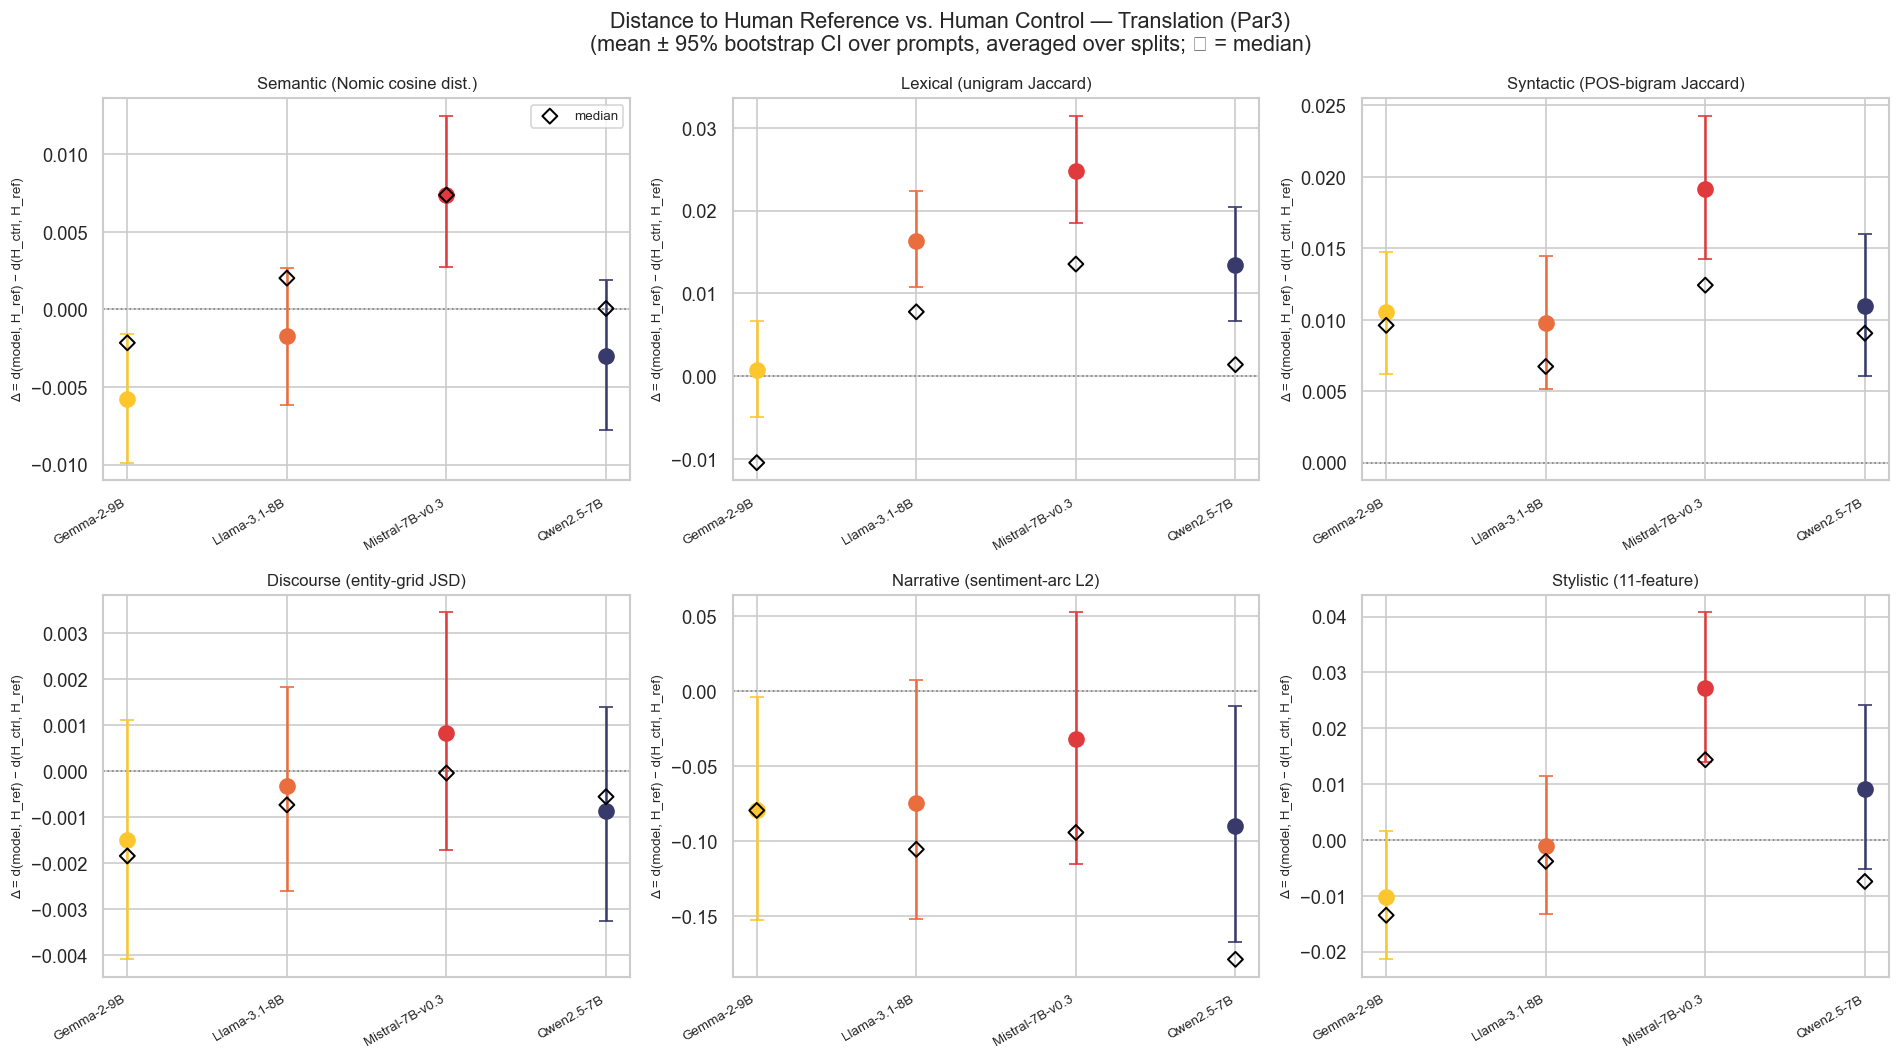

In [32]:
def plot_ci_by_metric(df_summary, ylabel, title, fname):
    """One panel per metric: mean +/- 95% bootstrap CI per model, open diamond = median."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()
    for ax, metric in zip(axes, PAIRING_METRICS):
        sub = df_summary[df_summary.metric == metric].set_index('source')
        order = [mk for mk in MODEL_SOURCES if mk in sub.index]
        ax.axhline(0, color='grey', linewidth=1, linestyle=':')
        for xi, mk in enumerate(order):
            row = sub.loc[mk]
            yerr = [[max(row['mean'] - row['ci_lo'], 0)], [max(row['ci_hi'] - row['mean'], 0)]]
            ax.errorbar(xi, row['mean'], yerr=yerr, fmt='o', color=MODEL_COLORS[MODEL_LABELS[mk]],
                        markersize=9, capsize=4, linewidth=1.5, zorder=3)
            ax.scatter(xi, row['median'], marker='D', s=40, facecolors='none', edgecolors='black',
                       linewidth=1.2, zorder=4, label='median' if (ax is axes[0] and xi == 0) else None)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels([MODEL_LABELS[mk] for mk in order], rotation=30, ha='right', fontsize=8)
        ax.set_title(METRIC_LABELS[metric], fontsize=10)
        ax.set_ylabel(ylabel, fontsize=8)
    axes[0].legend(fontsize=8, loc='best')
    fig.suptitle(title, fontsize=13)
    save_fig(fname)


plot_ci_by_metric(
    df_delta_summary, 'Δ = d(model, H_ref) − d(H_ctrl, H_ref)',
    'Distance to Human Reference vs. Human Control — Translation (Par3)\n'
    '(mean ± 95% bootstrap CI over prompts, averaged over splits; ◇ = median)',
    'delta_to_human_control_per_metric.png')

### Reference-Count Sensitivity: Exactly Three Human Translations

Repeats the prompt-level summary on the 132 paragraphs with exactly three humans, where every split has two references and exactly one control.


In [33]:
# Subset of prompts with exactly 3 human references, for a more controlled comparison
three_human_prompts = human_ref_counts.index[human_ref_counts == 3]

# Compute the same bootstrap summary for the exactly-3-humans subset
df_delta_3humans = (
    bootstrap_summary(df_delta_prompt[df_delta_prompt.prompt_id.isin(three_human_prompts)],
                      'delta', seed_base=3000)
    [['metric', 'source', 'n_prompts', 'mean', 'ci_lo', 'ci_hi']]
    .rename(columns={'mean': 'mean_3humans', 'ci_lo': 'ci_lo_3humans', 'ci_hi': 'ci_hi_3humans'})
)

df_delta_3humans.to_csv(TABLES_DIR / 'delta_to_human_control_exactly_3_humans.csv', index=False)

# Compare the main result (all prompts) with the exactly-3-humans subset
display(df_delta_summary.merge(df_delta_3humans, on=['metric', 'source'], how='left',
                               suffixes=('_main', '_3humans'))
        .rename(columns={'mean': 'mean_main'})
        [['metric', 'source',
          'n_prompts_main', 'mean_main', 'ci_lo', 'ci_hi',
          'n_prompts_3humans', 'mean_3humans', 'ci_lo_3humans', 'ci_hi_3humans']]
        .round(4))

,metric,source,n_prompts_main,mean_main,ci_lo,ci_hi,n_prompts_3humans,mean_3humans,ci_lo_3humans,ci_hi_3humans
0,D_sem,gemma,195,-0.0058,-0.0099,-0.0016,130,-0.0069,-0.0118,-0.0024
1,D_sem,llama,199,-0.0017,-0.0061,0.0027,132,-0.0019,-0.0071,0.0033
2,D_sem,mistral,199,0.0074,0.0027,0.0125,132,0.0051,-0.0001,0.0103
3,D_sem,qwen,180,-0.0030,-0.0078,0.0019,118,-0.0050,-0.0107,0.0004
4,D_lex,gemma,196,0.0008,-0.0049,0.0067,130,-0.0072,-0.0130,-0.0007
5,D_lex,llama,200,0.0164,0.0107,0.0223,132,0.0095,0.0030,0.0165
6,D_lex,mistral,200,0.0248,0.0185,0.0315,132,0.0165,0.0100,0.0237
7,D_lex,qwen,181,0.0134,0.0066,0.0204,118,0.0040,-0.0028,0.0116
8,D_syn,gemma,196,0.0105,0.0062,0.0148,130,0.0068,0.0015,0.0121
9,D_syn,llama,200,0.0098,0.0052,0.0145,132,0.0075,0.0020,0.0134


### Complete-Split Sensitivity: Full Reference/Control Coverage

Retains only the paragraphs where every one of the four models has its full expected number of splits


In [34]:
# Sensitivity analysis: retain only prompts where every model source has its full expected
# number of reference/control splits (C(n_human_refs, REF_SIZE)), i.e. no split lost to a
# missing/NaN distance.
split_counts = (
    df_delta_split
    .groupby(['metric', 'source', 'prompt_id'])
    .size()
    .reset_index(name='n_splits')
)
split_counts['complete'] = split_counts['n_splits'] == split_counts['prompt_id'].map(
    lambda pid: comb(human_ref_counts[pid], REF_SIZE))


# Identify prompts that have the full number of splits for every model source and every metric
prompt_status = split_counts.groupby(['metric', 'prompt_id']).agg(
    n_sources=('source', 'nunique'), all_complete=('complete', 'all'))
complete_prompts = prompt_status[
    (prompt_status.n_sources == len(MODEL_SOURCES)) & prompt_status.all_complete
].reset_index()[['metric', 'prompt_id']]


# Report the number of complete prompts for each metric
for metric in PAIRING_METRICS:
    n_complete = (complete_prompts.metric == metric).sum()
    print(metric, n_complete, 'complete prompts (of', len(split_prompts), ')')

# Compute the bootstrap summary for the subset of prompts that have complete splits for every model source and every metric
df_delta_complete = bootstrap_summary(
    df_delta_prompt.merge(complete_prompts, on=['metric', 'prompt_id'], how='inner'), 'delta')
df_delta_complete.to_csv(TABLES_DIR / 'delta_to_human_control_complete_prompts.csv', index=False)

display(df_delta_complete.round(4))

D_sem 178 complete prompts (of 200 )
D_lex 179 complete prompts (of 200 )
D_syn 179 complete prompts (of 200 )
D_disc 174 complete prompts (of 200 )
D_narr 153 complete prompts (of 200 )
D_style 179 complete prompts (of 200 )


,metric,source,model,n_prompts,mean,median,ci_lo,ci_hi
0,D_sem,gemma,Gemma-2-9B,178,-0.0037,-0.0012,-0.0080,0.0008
1,D_sem,llama,Llama-3.1-8B,178,0.0013,0.0037,-0.0033,0.0059
2,D_sem,mistral,Mistral-7B-v0.3,178,0.0102,0.0086,0.0054,0.0156
3,D_sem,qwen,Qwen2.5-7B,178,-0.0021,0.0001,-0.0069,0.0028
4,D_lex,gemma,Gemma-2-9B,179,0.0016,-0.0098,-0.0044,0.0080
5,D_lex,llama,Llama-3.1-8B,179,0.0186,0.0090,0.0125,0.0251
6,D_lex,mistral,Mistral-7B-v0.3,179,0.0270,0.0165,0.0204,0.0341
7,D_lex,qwen,Qwen2.5-7B,179,0.0138,0.0016,0.0071,0.0208
8,D_syn,gemma,Gemma-2-9B,179,0.0107,0.0100,0.0064,0.0154
9,D_syn,llama,Llama-3.1-8B,179,0.0119,0.0068,0.0071,0.0169


### Text-Level Human-Relative Distance Score (`r(t)`)

`r(t) = delta(t) / median(delta(t') for t' in that paragraph's human control texts)`. 

- Normalizing by the prompt-specific human-control median accounts for differences in the scale of human variation across inputs and facilitates comparison of human-relative distances across prompts.  
- `r(t) ~ 1` means `t` sits where a human control text could plausibly sit
- `r(t) >> 1` means it lands further from the reference than human variation typically reaches
- A zero human-control median (possible for D_lex/D_syn on short paragraphs) is treated as undefined
- `ref_dist_mean` (mean distance to both `H_ref` texts) is the primary variant
- `ref_dist_min` (distance to the nearer of the two `H_ref` texts) as a robustness variant

In [35]:
# Compute the mean and nearest-neighbor distance to H_ref for each text, averaged over all splits
rows_text = []
for metric in PAIRING_METRICS:
    for pid in split_prompts:

        # Only compute per-text deltas for prompts with enough human references
        M = pairing_matrices.get((metric, pid))
        if M is None:
            continue
        n = M.shape[0]

        # Initialize arrays to store the sum and count of mean and nearest-neighbor distances for each text
        sum_mean = np.zeros(n); cnt_mean = np.zeros(n)
        sum_min = np.zeros(n); cnt_min = np.zeros(n)

        # For each split of the human references into H_ref and H_ctrl, compute the mean and nearest-neighbor distance to H_ref for each text
        for split_id, ref_idx, row_mean, row_min in reference_control_splits_rowwise(
                M, int(human_ref_counts[pid]), REF_SIZE):

            # Only score texts that are eligible: a text is ineligible if it is part of the H_ref set for this split
            eligible = np.ones(n, dtype=bool)
            eligible[ref_idx] = False

            # Only accumulate scores for eligible texts that have a finite mean or nearest-neighbor distance to H_ref
            ok = eligible & np.isfinite(row_mean)
            sum_mean[ok] += row_mean[ok]; cnt_mean[ok] += 1
            ok = eligible & np.isfinite(row_min)
            sum_min[ok] += row_min[ok]; cnt_min[ok] += 1

        # Texts without any valid split get NaN
        ref_dist_mean = np.where(cnt_mean > 0, sum_mean / np.maximum(cnt_mean, 1), np.nan)
        ref_dist_min = np.where(cnt_min > 0, sum_min / np.maximum(cnt_min, 1), np.nan)

        # For each source in this prompt, record the per-text mean and nearest-neighbor distance to H_ref
        for src, (start, stop) in slices_by_prompt[pid].items():
            for local_idx, row_i in enumerate(range(start, stop)):
                if np.isfinite(ref_dist_mean[row_i]):
                    rows_text.append((metric, pid, src, local_idx,
                                      ref_dist_mean[row_i], ref_dist_min[row_i], int(cnt_mean[row_i])))

df_delta_text = pd.DataFrame(rows_text, columns=[
    'metric', 'prompt_id', 'source', 'local_idx', 'ref_dist_mean', 'ref_dist_min', 'n_splits'])
df_delta_text.to_csv(TABLES_DIR / 'hrd_delta_per_text.csv', index=False)

print(f'{len(df_delta_text):,} per-text deltas -> hrd_delta_per_text.csv')
print('splits averaged per text (varies with paragraph human-ref count):')
print(df_delta_text.groupby(df_delta_text.source.eq('human'))['n_splits'].value_counts().sort_index())

26,007 per-text deltas -> hrd_delta_per_text.csv
splits averaged per text (varies with paragraph human-ref count):
source  n_splits
False   2             143
        3           14369
        5              75
        6            7389
        10            102
True    1            2321
        2               8
        3            1570
        6              30
Name: count, dtype: int64


In [36]:
# r(t) = delta(t) / median(delta | human control, same metric+prompt).
ctrl = df_delta_text[df_delta_text.source == 'human']
ctrl_median = (ctrl.groupby(['metric', 'prompt_id'])[['ref_dist_mean', 'ref_dist_min']]
               .median()
               .rename(columns={'ref_dist_mean': 'ctrl_median_mean', 'ref_dist_min': 'ctrl_median_min'}))

# A zero human-control median makes r(t) undefined: count those and set them to NaN instead of inf
n_zero = (ctrl_median == 0).sum()
ctrl_median = ctrl_median.mask(ctrl_median == 0)

# Merge the per-text deltas with the human-control medians to compute the human-relative distance scores
df_score_text = df_delta_text.merge(ctrl_median, on=['metric', 'prompt_id'], how='left')
df_score_text['r_mean'] = df_score_text['ref_dist_mean'] / df_score_text['ctrl_median_mean']
df_score_text['r_min'] = df_score_text['ref_dist_min'] / df_score_text['ctrl_median_min']
df_score_text.to_csv(TABLES_DIR / 'hrd_score_per_text.csv', index=False)

print(f'{len(df_score_text):,} per-text human-relative distance scores -> hrd_score_per_text.csv')
print(f'(metric, prompt) pairs with a zero human-control median, set to NaN instead of inf: '
      f'{n_zero["ctrl_median_mean"]} (mean), {n_zero["ctrl_median_min"]} (min)')
df_score_text.groupby(['metric', 'source'])[['r_mean', 'r_min']].describe().round(3)

26,007 per-text human-relative distance scores -> hrd_score_per_text.csv
(metric, prompt) pairs with a zero human-control median, set to NaN instead of inf: 0 (mean), 8 (min)


r_mean                                                     \
                 count   mean    std    min    25%    50%    75%      max   
metric  source                                                              
D_disc  gemma    910.0  1.303  1.688  0.358  0.671  0.875  1.308   20.760   
        human    662.0  1.059  0.284  0.485  0.906  1.000  1.137    2.872   
        llama    973.0  1.728  6.184  0.358  0.698  0.947  1.430  104.774   
        mistral  956.0  1.687  5.485  0.358  0.726  0.977  1.472  118.140   
        qwen     807.0  1.523  3.109  0.358  0.719  0.954  1.498   70.331   
D_lex   gemma    933.0  1.017  0.083  0.871  0.970  0.998  1.032    1.560   
        human    669.0  1.008  0.072  0.805  0.986  1.000  1.026    1.489   
        llama    991.0  1.039  0.085  0.898  0.989  1.019  1.054    1.687   
        mistral  973.0  1.051  0.091  0.893  0.998  1.028  1.071    1.707   
        qwen     824.0  1.039  0.096  0.904  0.981  1.012  1.062    1.625   
D_narr  gemma    848.0  1.467  5.769  0.506  0.833  0.976  1.143   91.589   
        human    595.0  1.026  0.141  0.669  0.964  1.000  1.054    1.977   
        llama    903.0  1.527  6.747  0.507  0.829  0.981  1.142  111.424   
        mistral  898.0  1.611  7.627  0.502  0.841  0.980  1.165  128.955   
        qwen     758.0  1.614  7.275  0.503  0.832  0.952  1.143  110.728   
D_sem   gemma    928.0  1.199  0.764  0.564  0.818  0.976  1.314    7.550   
        human    665.0  1.053  0.214  0.687  0.925  1.000  1.112    2.251   
        llama    986.0  1.306  0.793  0.575  0.849  1.061  1.486    9.072   
        mistral  969.0  1.476  1.075  0.531  0.925  1.171  1.636   10.080   
        qwen     819.0  1.282  0.700  0.569  0.840  1.079  1.495    6.702   
D_style gemma    933.0  1.059  0.255  0.635  0.897  1.000  1.124    2.319   
        human    669.0  1.027  0.135  0.731  0.957  1.000  1.070    2.000   
        llama    991.0  1.074  0.279  0.645  0.909  1.016  1.154    4.004   
        mistral  973.0  1.143  0.354  0.659  0.947  1.051  1.222    4.642   
        qwen     824.0  1.123  0.348  0.671  0.907  1.015  1.205    3.139   
D_syn   gemma    933.0  1.065  0.161  0.699  0.965  1.042  1.129    2.084   
        human    669.0  1.014  0.115  0.775  0.973  1.000  1.044    2.000   
        llama    991.0  1.067  0.182  0.763  0.958  1.027  1.126    2.234   
        mistral  973.0  1.103  0.216  0.798  0.980  1.053  1.159    2.716   
        qwen     824.0  1.078  0.190  0.797  0.960  1.033  1.139    2.648   

                 r_min                                                      
                 count   mean     std    min    25%    50%    75%      max  
metric  source                                                              
D_disc  gemma    893.0  2.187   4.379  0.228  0.652  1.011  1.936   57.521  
        human    650.0  1.704   3.638  0.472  1.000  1.000  1.348   49.732  
        llama    955.0  3.256  12.444  0.228  0.718  1.159  2.218  198.422  
        mistral  937.0  3.022  11.328  0.230  0.741  1.217  2.191  223.843  
        qwen     787.0  2.644   6.051  0.224  0.739  1.217  2.258  104.156  
D_lex   gemma    933.0  1.072   0.267  0.844  0.973  1.007  1.056    3.212  
        human    669.0  1.027   0.192  0.539  1.000  1.000  1.049    3.080  
        llama    991.0  1.100   0.268  0.869  1.002  1.035  1.082    3.539  
        mistral  973.0  1.115   0.274  0.864  1.012  1.048  1.099    3.475  
        qwen     824.0  1.107   0.288  0.882  0.991  1.029  1.089    3.232  
D_narr  gemma    848.0  1.810   6.461  0.310  0.807  1.024  1.281   91.550  
        human    595.0  1.284   3.610  0.502  1.000  1.000  1.100   87.043  
        llama    903.0  1.876   7.548  0.335  0.819  1.023  1.295  111.415  
        mistral  898.0  1.997   8.267  0.336  0.823  1.035  1.341  128.943  
        qwen     758.0  2.116   8.417  0.336  0.808  1.008  1.306  110.665  
D_sem   gemma    928.0  2.810  17.228  0.409  0.830  1.119  1.733  371.245  
        hum

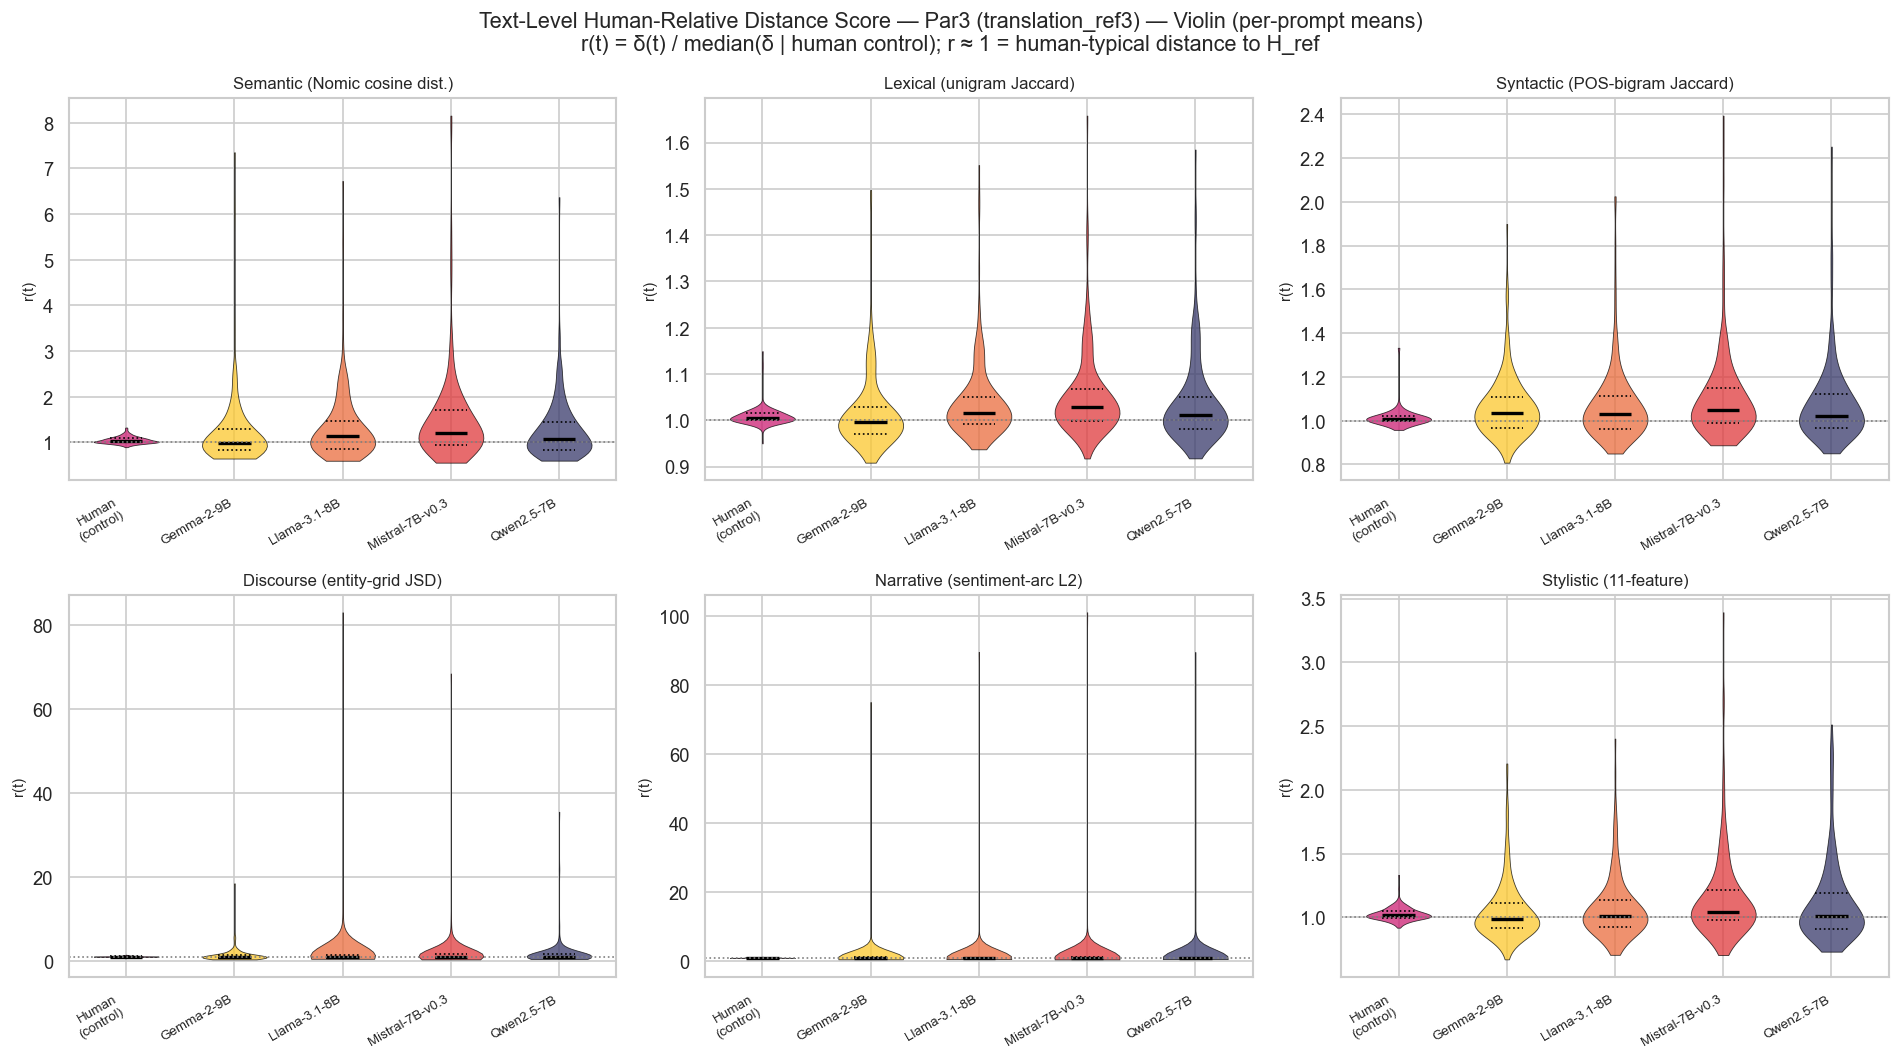

In [37]:
# Prompt-level violin: mean r(t) per (metric, source, prompt), one point per prompt
df_score_prompt = (df_score_text.groupby(['metric', 'source', 'prompt_id'])['r_mean']
                   .mean().reset_index())

source_labels = ['Human\n(control)'] + [MODEL_LABELS[mk] for mk in MODEL_SOURCES]
source_colors = [MODEL_COLORS[MODEL_LABELS[s]] for s in SOURCE_ORDER]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, metric in zip(axes.flat, PAIRING_METRICS):
    sub = df_score_prompt[df_score_prompt.metric == metric]
    data = [sub.loc[sub.source == s, 'r_mean'].dropna().values for s in SOURCE_ORDER]
    styled_violin(ax, data, source_labels, source_colors, rotation=30, ha='right', fontsize=8)
    ax.axhline(1.0, color='grey', linewidth=1, linestyle=':')
    ax.set_title(METRIC_LABELS[metric], fontsize=10)
    ax.set_ylabel('r(t)', fontsize=9)

fig.suptitle('Text-Level Human-Relative Distance Score \u2014 Par3 (translation_ref3) \u2014 Violin (per-prompt means)\n'
             'r(t) = \u03b4(t) / median(\u03b4 | human control); r \u2248 1 = human-typical distance to H_ref',
             fontsize=13)
save_fig('hrd_score_per_text_violin.png')

## Energy Distance: Human vs. Model (Raw Pairwise Distances)

$$E(H, M) = 2\,\overline{d(H, M)} - \overline{d(H, H')} - \overline{d(M, M')}$$

- The within-group means (`d(H, H')`, `d(M, M')`) are taken over the full `n^2` pairs
- Computed separately per `(metric, prompt, model)`, restricted to `ref_prompts`
- **NaN handling:**: a text with no defined representation for a metric is dropped from its group first


In [38]:
# Energy distance E(H, M) = 2*mean(d_HM) - mean(d_HH) - mean(d_MM), computed directly from the
# (metric, prompt) distance matrices in `pairing_matrices`
# Within-group means run over the full n**2 pairs

def _energy_stat(D, idx_h, idx_m):
    """D restricted to two disjoint index arrays -- assumes every remaining pair is finite."""

    # Compute the mean distance between the two groups (human and model)
    cross = D[np.ix_(idx_h, idx_m)]
    d_hm = cross[np.isfinite(cross)].mean()

    # Compute the mean distance within each group (human and model)
    def within_mean(idx):
        k = len(idx)

        # Only consider the upper triangle of the submatrix to avoid double-counting distances
        vals = D[np.ix_(idx, idx)][np.triu_indices(k, k=1)]
        vals = vals[np.isfinite(vals)]

        # Return the mean of the off-diagonal distances, scaled by the number of pairs
        return (2 * vals.sum()) / (k * k)   # off-diag sum (x2, symmetric) / k**2 -> zero self-dist. included

    return 2 * d_hm - within_mean(idx_h) - within_mean(idx_m)


def pooled_block(D, idx_h, idx_m):
    """Sub-matrix of D over [idx_h | idx_m] with a zero diagonal."""

    # Concatenate the human and model indices to form a single pool of indices
    pool = np.concatenate([idx_h, idx_m])
    block = D[np.ix_(pool, pool)].copy()
    np.fill_diagonal(block, 0.0)

    return block


def energy_distance_hm(D, idx_h, idx_m):
    """Drops texts with no defined distance to anything (all-nan row) from both groups, then
    verifies every remaining pair is actually finite.

    Returns (energy_dist, valid_idx_h, valid_idx_m); (nan, ..., ...) if a group has < 2 valid
    texts left. Raises ValueError if a defined-but-partial nan remains after filtering.
    """

    # Create a copy of the distance matrix and fill the diagonal with NaN to ignore self-distances
    D_check = D.copy()
    np.fill_diagonal(D_check, np.nan)
    valid = np.isfinite(D_check).any(axis=1)

    # Filter the human and model indices to only include those that have at least one finite distance
    idx_h_v = np.asarray([i for i in idx_h if valid[i]])
    idx_m_v = np.asarray([i for i in idx_m if valid[i]])

    # If either group has fewer than 2 valid texts, return NaN for the energy distance
    if len(idx_h_v) < 2 or len(idx_m_v) < 2:
        return np.nan, idx_h_v, idx_m_v

    # Verify that the pooled submatrix of D over the valid human and model indices contains only finite values
    if not np.isfinite(pooled_block(D, idx_h_v, idx_m_v)).all():
        raise ValueError("Partial NaNs remain after removing invalid texts.")
    return _energy_stat(D, idx_h_v, idx_m_v), idx_h_v, idx_m_v


def human_model_indices(pid):
    """Yield (model_source, idx_h, idx_m) row indices into prompt `pid`'s matrices."""
    slices = slices_by_prompt[pid]
    idx_h = np.arange(*slices['human'])
    for src, _ in segments_by_prompt[pid][1:]:
        yield src, idx_h, np.arange(*slices[src])

In [39]:
def energy_permutation_test(block, n_h, exact_limit=20_000, n_perm=9_999, seed=0):
    """Prompt-wise permutation test for E(H, M) on a `pooled_block` whose first `n_h` rows
    are the (already NaN-filtered) human texts.

    H0: the Human/Model group labels are exchangeable within this prompt's pool. Every
    one of the C(n, n_h) possible label splits is enumerated when that count is
    <= `exact_limit` for an exact p-value (always true at the group sizes seen here,
    pool size <= ~10); otherwise falls back to a fixed-seed Monte Carlo permutation test
    with `n_perm` draws.

    Returns (p_perm, n_splits_used, exact) -- one-sided p-value for E_perm >= E_obs.
    """

    # Compute the observed energy statistic for the given block and human/model split
    n = block.shape[0]
    pos = np.arange(n)
    e_obs = _energy_stat(block, pos[:n_h], pos[n_h:])
    n_exact = comb(n, n_h)

    # If the number of exact permutations is small enough, enumerate them all to compute the exact p-value
    if n_exact <= exact_limit:
        ge = 0

        # Generate all combinations of indices for the human group of size `n_h` from the total pool of size `n`
        for combo in combinations(range(n), n_h):
            idx_h_p = np.array(combo)
            mask = np.ones(n, dtype=bool)
            mask[idx_h_p] = False

            # Compute the energy statistic for this permutation and check if it is greater than or 
            # equal to the observed statistic
            if _energy_stat(block, idx_h_p, pos[mask]) >= e_obs - 1e-9:
                ge += 1

        return ge / n_exact, n_exact, True

    # Otherwise, perform a Monte Carlo permutation test with a fixed number of random permutations
    rng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        perm = rng.permutation(pos)
        if _energy_stat(block, perm[:n_h], perm[n_h:]) >= e_obs - 1e-9:
            ge += 1
            
    return (ge + 1) / (n_perm + 1), n_perm, False

In [40]:
rows_energy = []
n_partial_nan = 0
energy_valid_blocks = {}  # (metric, prompt_id, source) -> (pooled_block, n_h_eff), reused by the group-level permutation test below

for metric in PAIRING_METRICS:
    for pid in ref_prompts:

        # Only compute energy distances for prompts with enough human references
        M = pairing_matrices.get((metric, pid))
        if M is None:
            continue

        # Compute the energy distance for each model source relative to the human references
        for src, idx_h, idx_m in human_model_indices(pid):
            # A ValueError means a stray NaN remains within the valid pool -> excluded as NaN
            try:
                e_obs, idx_h_v, idx_m_v = energy_distance_hm(M, idx_h, idx_m)
            except ValueError:
                e_obs, idx_h_v, idx_m_v = np.nan, np.array([], dtype=int), np.array([], dtype=int)
                n_partial_nan += 1

            # Prompt-wise permutation test: exact label-split enumeration at these
            # group sizes, Monte Carlo fallback for larger pools
            if np.isfinite(e_obs):
                block = pooled_block(M, idx_h_v, idx_m_v)
                p_perm, n_perm_used, perm_exact = energy_permutation_test(block, len(idx_h_v))
                energy_valid_blocks[(metric, pid, src)] = (block, len(idx_h_v))
            else:
                p_perm, n_perm_used, perm_exact = np.nan, 0, False

            rows_energy.append({'metric': metric, 'prompt_id': pid, 'source': src, 'energy_dist': e_obs,
                                'n_human_eff': len(idx_h_v), 'n_model_eff': len(idx_m_v),
                                'p_perm': p_perm, 'n_perm_used': n_perm_used, 'perm_exact': perm_exact})

df_energy_per_prompt = pd.DataFrame(rows_energy)
df_energy_per_prompt.to_csv(TABLES_DIR / 'energy_distance_per_prompt.csv', index=False)
print(f'{len(df_energy_per_prompt)} (metric, prompt, model) energy distances ({len(ref_prompts)} ref_prompts); '
      f'{n_partial_nan} flagged with a stray within-valid-pool NaN (-> nan, excluded) '
      f'-> energy_distance_per_prompt.csv')
df_energy_per_prompt.groupby(['metric', 'source'])['energy_dist'].describe().round(4)

4658 (metric, prompt, model) energy distances (200 ref_prompts); 0 flagged with a stray within-valid-pool NaN (-> nan, excluded) -> energy_distance_per_prompt.csv


count    mean     std     min     25%     50%     75%     max
metric  source                                                                
D_disc  gemma    193.0  0.0233  0.0268  0.0009  0.0071  0.0142  0.0286  0.2166
        llama    198.0  0.0218  0.0234  0.0006  0.0073  0.0143  0.0258  0.1777
        mistral  197.0  0.0240  0.0272  0.0011  0.0085  0.0154  0.0271  0.1813
        qwen     179.0  0.0227  0.0223  0.0007  0.0074  0.0155  0.0304  0.1220
D_lex   gemma    196.0  0.5689  0.0688  0.4417  0.5251  0.5545  0.5986  0.7960
        llama    200.0  0.5122  0.0535  0.3633  0.4775  0.5073  0.5417  0.7127
        mistral  200.0  0.5787  0.0582  0.4244  0.5425  0.5766  0.6042  0.8064
        qwen     181.0  0.5440  0.0776  0.3731  0.4990  0.5326  0.5870  0.8184
D_narr  gemma    180.0  1.9771  0.9491  0.6038  1.2994  1.7831  2.4761  6.3416
        llama    184.0  1.8190  0.8419  0.3709  1.2247  1.6540  2.2477  6.4897
        mistral  185.0  2.0065  0.9797  0.5210  1.2542  1.8213  2.4650  7.2773
        qwen     168.0  1.8762  0.8985  0.5550  1.2671  1.7171  2.3466  5.7930
D_sem   gemma    195.0  0.0631  0.0481  0.0090  0.0314  0.0516  0.0798  0.4242
        llama    199.0  0.0627  0.0415  0.0077  0.0321  0.0537  0.0845  0.3803
        mistral  199.0  0.0817  0.0635  0.0105  0.0429  0.0668  0.0982  0.5823
        qwen     180.0  0.0612  0.0483  0.0082  0.0315  0.0497  0.0785  0.4610
D_style gemma    196.0  0.5017  0.1788  0.1597  0.3684  0.4829  0.6048  1.2366
        llama    200.0  0.4544  0.1662  0.1827  0.3364  0.4503  0.5442  1.2389
        mistral  200.0  0.5429  0.1824  0.2054  0.4131  0.5146  0.6487  1.3121
        qwen     181.0  0.5005  0.1851  0.1483  0.3722  0.4761  0.5889  1.1714
D_syn   gemma    196.0  0.2818  0.0708  0.1252  0.2346  0.2769  0.3273  0.6163
        llama    200.0  0.2416  0.0574  0.1273  0.1987  0.2399  0.2745  0.5581
        mistral  200.0  0.2807  0.0652  0.1429  0.2366  0.2749  0.3210  0.5556
        qwen     181.0  0.2623  0.0736  0.1094  0.2078  0.2539  0.3057  0.6323

In [41]:
# Every prompt where this (metric, model) pair has a finite energy_dist is eligible -- no
# longer restricted to the intersection across all four models
df_energy_summary = bootstrap_summary(df_energy_per_prompt, 'energy_dist')

# Fraction of eligible prompts where the prompt-wise permutation test rejects H0 at alpha = 0.05
frac_sig_05 = (df_energy_per_prompt.dropna(subset=['p_perm'])
               .assign(sig=lambda d: d.p_perm < 0.05)
               .groupby(['metric', 'source'])['sig'].mean().rename('frac_sig_05').reset_index())
df_energy_summary = df_energy_summary.merge(frac_sig_05, on=['metric', 'source'], how='left')
df_energy_summary.round(4)

,metric,source,model,n_prompts,mean,median,ci_lo,ci_hi,frac_sig_05
0,D_sem,gemma,Gemma-2-9B,195,0.0631,0.0516,0.0568,0.0700,0.8000
1,D_sem,llama,Llama-3.1-8B,199,0.0627,0.0537,0.0572,0.0687,0.7437
2,D_sem,mistral,Mistral-7B-v0.3,199,0.0817,0.0668,0.0733,0.0910,0.8794
3,D_sem,qwen,Qwen2.5-7B,180,0.0612,0.0497,0.0547,0.0688,0.7000
4,D_lex,gemma,Gemma-2-9B,196,0.5689,0.5545,0.5596,0.5788,0.9235
5,D_lex,llama,Llama-3.1-8B,200,0.5122,0.5073,0.5048,0.5199,0.9950
6,D_lex,mistral,Mistral-7B-v0.3,200,0.5787,0.5766,0.5709,0.5868,0.9800
7,D_lex,qwen,Qwen2.5-7B,181,0.5440,0.5326,0.5326,0.5555,0.9282
8,D_syn,gemma,Gemma-2-9B,196,0.2818,0.2769,0.2721,0.2918,0.9235
9,D_syn,llama,Llama-3.1-8B,200,0.2416,0.2399,0.2339,0.2500,0.9100


In [42]:
# Inferential test per (metric, model): Monte Carlo permutation test

N_GROUP_PERM = 9_999
GROUP_PERM_SEED = 0
_group_perm_rng = np.random.default_rng(GROUP_PERM_SEED)


def energy_group_permutation_pvalue(metric, mk, observed_mean, rng, n_iter=N_GROUP_PERM):
    """Monte Carlo permutation test for the mean energy_dist across every eligible prompt
    of this (metric, model) -> the same pooled distance blocks that produced `observed_mean`.

    In each of `n_iter` draws, the Human/Model labels are reshuffled independently within
    every prompt's own pool and energy_dist recomputed; the per-prompt values are averaged
    into one null mean. One-sided p-value for P(null_mean >= observed_mean).
    """
    # Identify the pooled distance blocks for this (metric, model) pair across all eligible prompts
    blocks = [energy_valid_blocks[(metric, pid, mk)] for pid in ref_prompts
              if (metric, pid, mk) in energy_valid_blocks]
    if not blocks:
        return np.nan

    # Compute the null distribution of mean energy distances by permuting the labels within each prompt's block
    null_means = np.zeros(n_iter)
    for block, n_h in blocks:

        # Shuffle the labels within each prompt's block
        n = block.shape[0]
        n_m = n - n_h
        order = np.argsort(rng.random((n_iter, n)), axis=1)
        idx_h, idx_m = order[:, :n_h], order[:, n_h:]

        # Compute the energy distance for each permutation and accumulate the null means
        cross = block[idx_h[:, :, None], idx_m[:, None, :]].sum(axis=(1, 2)) / (n_h * n_m)
        within_h = block[idx_h[:, :, None], idx_h[:, None, :]].sum(axis=(1, 2)) / (n_h * n_h)
        within_m = block[idx_m[:, :, None], idx_m[:, None, :]].sum(axis=(1, 2)) / (n_m * n_m)

        null_means += 2 * cross - within_h - within_m

    # Average the null means over all prompts to get the overall null distribution
    null_means /= len(blocks)
    ge = int(np.sum(null_means >= observed_mean - 1e-9))
    return (ge + 1) / (n_iter + 1)


df_energy_summary['p_group'] = [
    energy_group_permutation_pvalue(row['metric'], row['source'], row['mean'], _group_perm_rng)
    for _, row in df_energy_summary.iterrows()
]

_, p_group_fdr, _, _ = multipletests(df_energy_summary['p_group'], alpha=0.05, method='fdr_bh')
df_energy_summary['p_group_fdr'] = p_group_fdr
df_energy_summary['sig_fdr_05'] = df_energy_summary['p_group_fdr'] < 0.05

df_energy_summary.to_csv(TABLES_DIR / 'energy_distance_summary.csv', index=False)
print(f'Group-level permutation test (n_iter={N_GROUP_PERM}) + Benjamini-Hochberg FDR over '
      f'{len(df_energy_summary)} (metric, model) tests -> energy_distance_summary.csv')
df_energy_summary.round(4)

Group-level permutation test (n_iter=9999) + Benjamini-Hochberg FDR over 24 (metric, model) tests -> energy_distance_summary.csv


,metric,source,model,n_prompts,mean,median,ci_lo,ci_hi,frac_sig_05,p_group,p_group_fdr,sig_fdr_05
0,D_sem,gemma,Gemma-2-9B,195,0.0631,0.0516,0.0568,0.0700,0.8000,0.0001,0.0001,True
1,D_sem,llama,Llama-3.1-8B,199,0.0627,0.0537,0.0572,0.0687,0.7437,0.0001,0.0001,True
2,D_sem,mistral,Mistral-7B-v0.3,199,0.0817,0.0668,0.0733,0.0910,0.8794,0.0001,0.0001,True
3,D_sem,qwen,Qwen2.5-7B,180,0.0612,0.0497,0.0547,0.0688,0.7000,0.0001,0.0001,True
4,D_lex,gemma,Gemma-2-9B,196,0.5689,0.5545,0.5596,0.5788,0.9235,0.0001,0.0001,True
5,D_lex,llama,Llama-3.1-8B,200,0.5122,0.5073,0.5048,0.5199,0.9950,0.0001,0.0001,True
6,D_lex,mistral,Mistral-7B-v0.3,200,0.5787,0.5766,0.5709,0.5868,0.9800,0.0001,0.0001,True
7,D_lex,qwen,Qwen2.5-7B,181,0.5440,0.5326,0.5326,0.5555,0.9282,0.0001,0.0001,True
8,D_syn,gemma,Gemma-2-9B,196,0.2818,0.2769,0.2721,0.2918,0.9235,0.0001,0.0001,True
9,D_syn,llama,Llama-3.1-8B,200,0.2416,0.2399,0.2339,0.2500,0.9100,0.0001,0.0001,True


/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_87760/1912579384.py:18: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_87760/1912579384.py:19: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / name, dpi=FIG_DPI, bbox_inches='tight')
/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/llm-linguistic-diversity/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9671 (\N{WHITE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


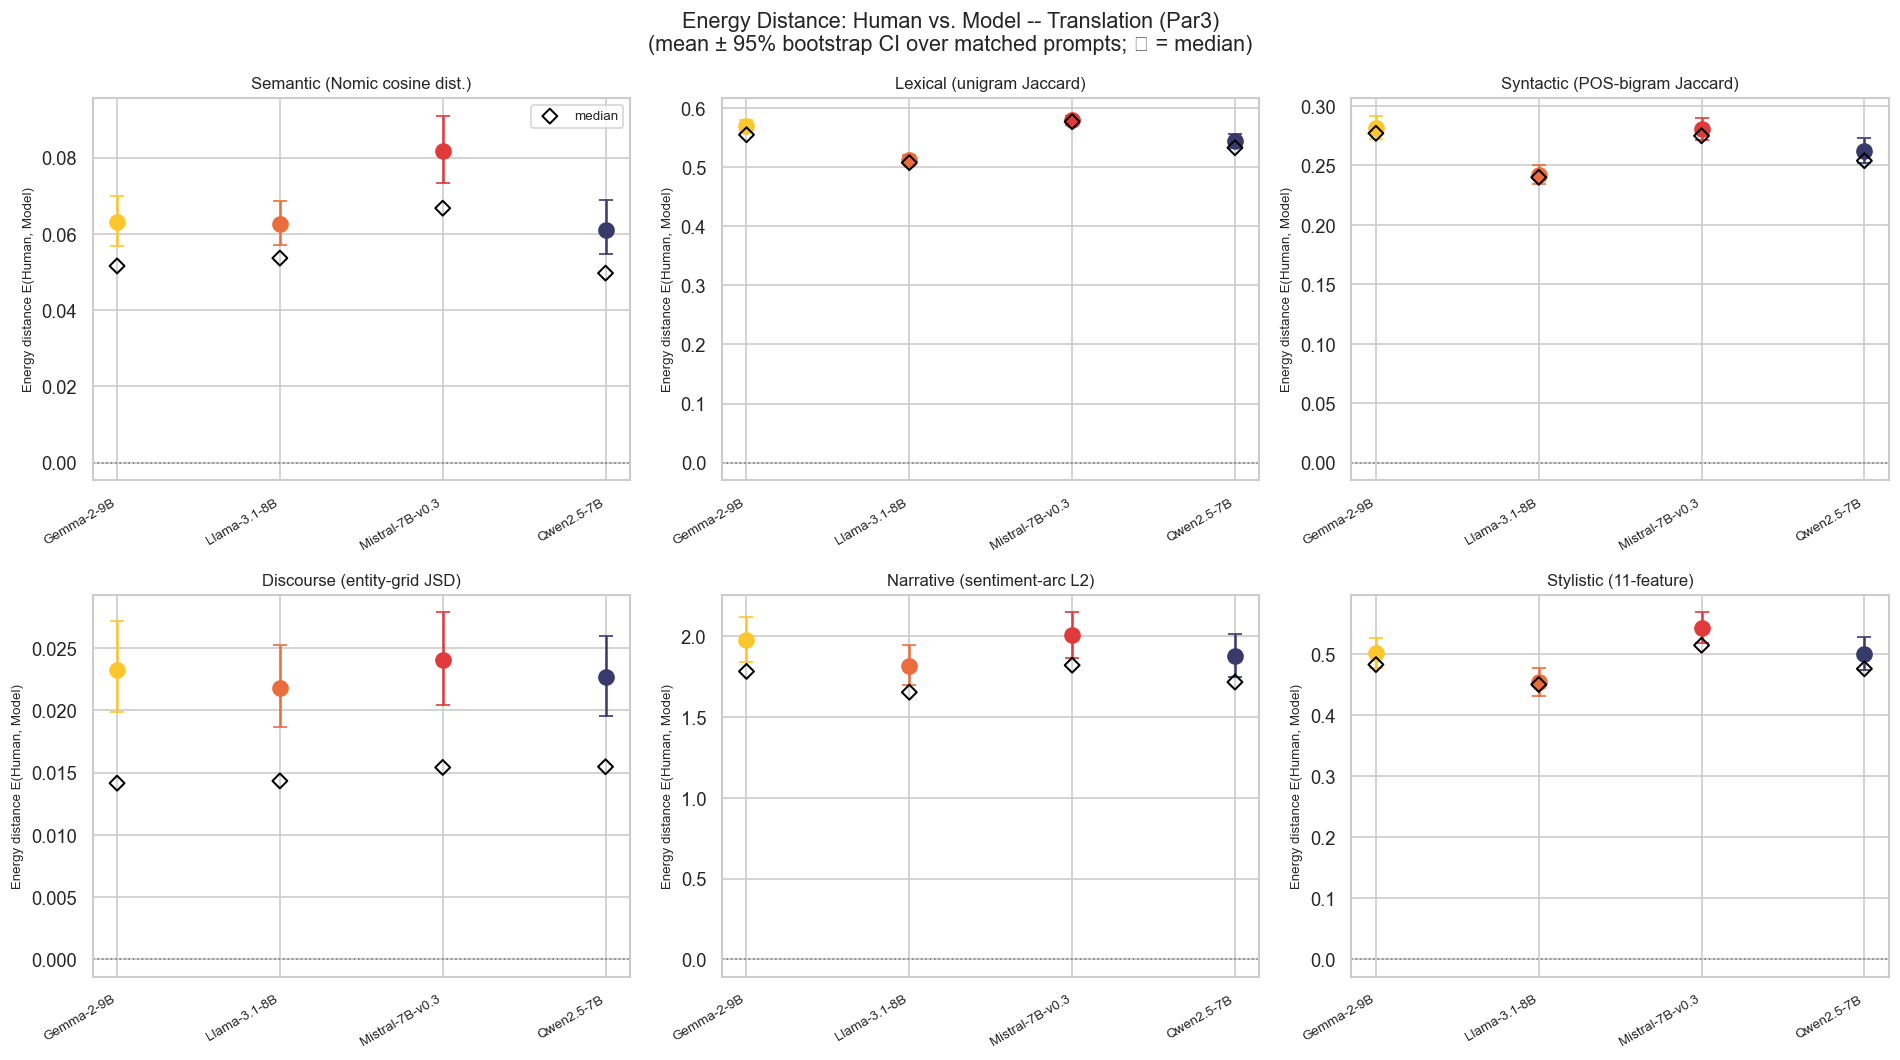

In [43]:
plot_ci_by_metric(
    df_energy_summary, 'Energy distance E(Human, Model)',
    'Energy Distance: Human vs. Model -- Translation (Par3)\n'
    '(mean \u00b1 95% bootstrap CI over matched prompts; \u25c7 = median)',
    'energy_distance_per_metric.png')

## Length Robustness Check (Human-Relative Location)

1. **Length gap:** does mean text length differ between Human and each model, per `ref_prompts`?
2. **Split-matched length confounds (`delta_L`, `energy_L`)**

In [44]:
def _mean_len(texts):
    lens = [len(word_tokenize_simple(t)) for t in texts]
    return float(np.mean(lens)) if lens else np.nan


# Mean text length per prompt and source (human and every model, incl. models with < 2 samples)
rows_len = []
for pid in ref_prompts:

    # Compute the mean text length for the human references and each model source for this prompt
    hum = human_translations_by_prompt[pid]
    rows_len.append({'prompt_id': pid, 'source': 'human', 'mean_len': _mean_len(hum), 'n_texts': len(hum)})

    # Compute the mean text length for each model source for this prompt
    for mk in MODEL_SOURCES:
        mt = model_texts.get((mk, pid), [])
        rows_len.append({'prompt_id': pid, 'source': mk, 'mean_len': _mean_len(mt), 'n_texts': len(mt)})


df_length = pd.DataFrame(rows_len)
df_length.to_csv(TABLES_DIR / 'text_length_per_prompt.csv', index=False)

print(f'Text length computed for {len(ref_prompts)} ref_prompts x {len(SOURCE_ORDER)} sources '
      f'-> text_length_per_prompt.csv')
df_length.groupby('source')['mean_len'].describe().reindex(SOURCE_ORDER).round(1)

Text length computed for 200 ref_prompts x 5 sources -> text_length_per_prompt.csv


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
human,200.0,414.6,440.1,66.0,237.8,301.3,418.8,4530.2
gemma,199.0,369.3,284.8,56.6,217.9,284.0,393.2,2131.2
llama,200.0,382.7,265.4,57.0,230.6,307.8,434.2,1675.2
mistral,200.0,391.5,271.5,80.8,233.4,310.9,437.0,1813.8
qwen,191.0,363.1,267.9,56.8,217.7,281.8,389.2,1697.2


### Length Confound (`delta_L`, `energy_L`)


In [45]:
# Length "distance matrix" per ref_prompt: |len_i - len_j| over [human | model_1 | ...],
# same layout as pairing_matrices
length_matrices = {}
for pid in ref_prompts:
    lens = np.array([len(word_tokenize_simple(t)) for t in texts_by_prompt[pid]], dtype=float)
    length_matrices[pid] = np.abs(lens[:, None] - lens[None, :])

print(f'Length-distance matrices built for {len(length_matrices)} ref_prompts')

Length-distance matrices built for 200 ref_prompts


In [46]:
# delta_L: identical recipe to "Matched Reference/Control Split" + "Delta to Human Control"
# above, rerun on length_matrices instead of a diversity-metric matrix
rows_split_len = [(pid, *row) for pid in split_prompts
                  for row in split_distance_rows(length_matrices[pid], pid)]
df_split_len_long = pd.DataFrame(
    rows_split_len, columns=['prompt_id', 'split_id', 'source', 'pairing', 'dist'])
df_split_len_long.to_csv(TABLES_DIR / 'length_split_distances_long.csv', index=False)

# Compute delta_L = mean(dist | human-model) - mean(dist | human-human), per (source, prompt_id, split_id)
df_delta_L_split = delta_per_split(df_split_len_long).rename(columns={'delta': 'delta_L'})
df_delta_L_prompt = (df_delta_L_split.groupby(['source', 'prompt_id'])['delta_L']
                     .mean().reset_index())
df_delta_L_prompt.to_csv(TABLES_DIR / 'length_delta_L_per_prompt.csv', index=False)


# Check that every prompt has the same number of splits (3, 6 or 10) and report the distribution
n_splits_len = df_delta_L_split.groupby(['source', 'prompt_id']).size()
print(f'{len(df_delta_L_prompt)} (model, prompt) delta_L values, splits/prompt averaged: '
      f'{sorted(n_splits_len.unique())} -> length_delta_L_per_prompt.csv')
df_delta_L_prompt.groupby('source')['delta_L'].describe().round(3)

777 (model, prompt) delta_L values, splits/prompt averaged: [np.int64(3), np.int64(6), np.int64(10)] -> length_delta_L_per_prompt.csv


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
gemma,196.0,14.986,179.486,-79.333,-14.683,-1.108,12.617,2202.217
llama,200.0,15.226,229.092,-101.333,-14.750,-4.050,8.113,3024.217
mistral,200.0,52.616,244.728,-93.433,-9.233,11.500,38.250,2852.167
qwen,181.0,25.237,215.161,-78.083,-10.400,1.633,15.867,2636.217


In [47]:
# energy_L: identical construction to the Energy Distance section above
rows_energy_len = []
for pid in ref_prompts:
    for src, idx_h, idx_m in human_model_indices(pid):
        try:
            e_obs, _, _ = energy_distance_hm(length_matrices[pid], idx_h, idx_m)
        except ValueError:
            e_obs = np.nan
        rows_energy_len.append({'prompt_id': pid, 'source': src, 'energy_L': e_obs})


df_energy_L_prompt = pd.DataFrame(rows_energy_len)
df_energy_L_prompt.to_csv(TABLES_DIR / 'length_energy_L_per_prompt.csv', index=False)

print(f'{len(df_energy_L_prompt)} (model, prompt) energy_L values -> length_energy_L_per_prompt.csv')
df_energy_L_prompt.groupby('source')['energy_L'].describe().round(3)

777 (model, prompt) energy_L values -> length_energy_L_per_prompt.csv


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
gemma,196.0,87.924,372.717,1.911,23.602,35.622,63.726,4634.315
llama,200.0,85.019,454.437,1.022,14.709,28.676,50.196,5990.315
mistral,200.0,119.731,455.701,2.044,24.207,44.013,76.871,5379.000
qwen,181.0,104.119,446.272,2.140,25.045,37.973,64.880,5497.035


### Length vs. Location Correlation

Spearman correlation between each location metric and its length-only counterpart, per `(metric, model)`, over `ref_prompts`: `delta` vs. `delta_L`, and `energy_dist` vs. `energy_L`

In [48]:
def _length_confound_table(df_metric_prompt, value_col, cov_df, cov_col, out_name):
    """Spearman rho(cov_col, value_col), per (metric, model), over ref_prompts."""
    rows = []
    for metric in PAIRING_METRICS:
        for mk in MODEL_SOURCES:
            sub = df_metric_prompt[(df_metric_prompt.metric == metric) & (df_metric_prompt.source == mk)]
            merged = sub.merge(cov_df[['prompt_id', 'source', cov_col]],
                               on=['prompt_id', 'source'], how='inner').dropna(subset=[value_col, cov_col])

            # Only compute Spearman correlation if there are enough data points to avoid unreliable estimates
            if len(merged) < 5:
                continue

            rho, p = spearmanr(merged[cov_col], merged[value_col])
            rows.append({'metric': metric, 'source': mk, 'model': MODEL_LABELS[mk],
                         'rho_length': rho, 'p_length': p, 'n': len(merged)})
    df = pd.DataFrame(rows)
    df.to_csv(TABLES_DIR / f'length_confound_{out_name}.csv', index=False)
    return df


def show_by_model(df, value_col, digits):
    """Display `value_col` as a model x metric table."""
    display(df.pivot(index='model', columns='metric', values=value_col).reindex(GEN_ORDER).round(digits))


df_length_confound_delta = _length_confound_table(
    df_delta_prompt, 'delta', df_delta_L_prompt, 'delta_L', 'delta')
df_length_confound_energy = _length_confound_table(
    df_energy_per_prompt, 'energy_dist', df_energy_L_prompt, 'energy_L', 'energy')

print('Spearman rho(delta_L, delta) -- Delta to Human Control, per (metric, model):')
show_by_model(df_length_confound_delta, 'rho_length', 3)
print('\nSpearman rho(energy_L, energy_dist) -- Energy Distance, per (metric, model):')
show_by_model(df_length_confound_energy, 'rho_length', 3)

Spearman rho(delta_L, delta) -- Delta to Human Control, per (metric, model):


metric,D_disc,D_lex,D_narr,D_sem,D_style,D_syn
model,,,,,,
Gemma-2-9B,0.286,0.388,0.086,0.451,0.458,0.162
Llama-3.1-8B,0.251,0.458,0.153,0.384,0.456,0.377
Mistral-7B-v0.3,0.227,0.404,0.190,0.337,0.388,0.384
Qwen2.5-7B,0.320,0.545,0.137,0.373,0.501,0.460



Spearman rho(energy_L, energy_dist) -- Energy Distance, per (metric, model):


metric,D_disc,D_lex,D_narr,D_sem,D_style,D_syn
model,,,,,,
Gemma-2-9B,-0.444,-0.116,-0.350,-0.041,-0.138,-0.307
Llama-3.1-8B,-0.278,-0.079,-0.284,-0.017,-0.088,-0.310
Mistral-7B-v0.3,-0.389,-0.090,-0.274,-0.134,-0.225,-0.411
Qwen2.5-7B,-0.351,-0.070,-0.335,-0.089,-0.131,-0.348


## Length-Adjusted Sensitivity Analysis (delta vs. delta_L)

Does accounting for `delta_L` shift the direction or magnitude of the model-specific `delta` pattern

For each dimension, a no-intercept OLS on prompt-level `delta`:

$$\text{delta} = \sum_{m} \beta_m \cdot \mathbb{1}[\text{source}=m] + \beta_{L} \cdot (\text{delta\_L} - \overline{\text{delta\_L}}) + \varepsilon$$

- `delta_L` is centered within each dimension's own regression sample
- No intercept (`0 + C(source) + delta_L_c`): each `beta_m` is directly the
  length-adjusted mean `delta` for that model, evaluated at the sample's average
  `delta_L`
- **Prompt-clustered standard errors** (`cov_type='cluster'`, grouped by `prompt_id`),
  since each prompt contributes one observation per model and these are not independent
  draws


In [49]:
# Sensitivity check: controlling for delta_L 
df_delta_sens = df_delta_prompt.merge(
    df_delta_L_prompt[['prompt_id', 'source', 'delta_L']],
    on=['prompt_id', 'source'], how='inner',
).dropna(subset=['delta', 'delta_L'])

sens_rows = []
for metric in PAIRING_METRICS:

    # Subset to this metric and check that there are enough sources and prompts to run a regression
    sub = df_delta_sens[df_delta_sens.metric == metric].copy()
    if sub['source'].nunique() < 2 or len(sub) < 20:
        print(f'{metric}: skipped -- insufficient data for regression')
        continue

    # Center delta_L within this metric's own regression sample
    sub['delta_L_c'] = sub['delta_L'] - sub['delta_L'].mean()

    # Fit a linear regression model with delta as the dependent variable
    fit = smf.ols('delta ~ 0 + C(source) + delta_L_c', data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['prompt_id']})

    # Extract the confidence intervals, coefficients and p-values for the regression terms
    ci = fit.conf_int()
    length_coef = fit.params.get('delta_L_c', np.nan)
    length_p = fit.pvalues.get('delta_L_c', np.nan)

    for term in fit.params.index:
        if not term.startswith('C(source)['):
            continue
        mk = term[len('C(source)['):-1]
        unadj_mean = sub.loc[sub.source == mk, 'delta'].mean()
        adj_mean = fit.params[term]
        sens_rows.append({
            'metric': metric, 'source': mk, 'model': MODEL_LABELS[mk],
            'n': int((sub.source == mk).sum()),
            'unadj_mean_delta': unadj_mean,
            'adj_mean_delta': adj_mean,
            'adj_ci_lo': ci.loc[term, 0], 'adj_ci_hi': ci.loc[term, 1],
            'shift': adj_mean - unadj_mean,
            'length_coef': length_coef, 'length_p': length_p,
        })

df_delta_sensitivity = pd.DataFrame(sens_rows)
df_delta_sensitivity.to_csv(TABLES_DIR / 'delta_length_sensitivity.csv', index=False)
print(f'Length-adjusted sensitivity analysis ({len(df_delta_sensitivity)} rows) -> '
      f'delta_length_sensitivity.csv')

for col, title in [('unadj_mean_delta', 'Unadjusted mean delta:'),
                   ('adj_mean_delta', 'Length-adjusted mean delta (at average delta_L):'),
                   ('shift', 'Shift (adjusted - unadjusted):')]:
    print('\n' + title)
    show_by_model(df_delta_sensitivity, col, 4)

Length-adjusted sensitivity analysis (24 rows) -> delta_length_sensitivity.csv

Unadjusted mean delta:


metric,D_disc,D_lex,D_narr,D_sem,D_style,D_syn
model,,,,,,
Gemma-2-9B,-0.0015,0.0008,-0.0792,-0.0058,-0.0102,0.0105
Llama-3.1-8B,-0.0003,0.0164,-0.0745,-0.0017,-0.0011,0.0098
Mistral-7B-v0.3,0.0008,0.0248,-0.0322,0.0074,0.0271,0.0191
Qwen2.5-7B,-0.0009,0.0134,-0.0901,-0.0030,0.0090,0.0110



Length-adjusted mean delta (at average delta_L):


metric,D_disc,D_lex,D_narr,D_sem,D_style,D_syn
model,,,,,,
Gemma-2-9B,-0.0015,0.0017,-0.0743,-0.0042,-0.0088,0.0111
Llama-3.1-8B,-0.0003,0.0173,-0.0698,0.0005,0.0002,0.0103
Mistral-7B-v0.3,0.0007,0.0228,-0.0426,0.0031,0.0243,0.0180
Qwen2.5-7B,-0.0009,0.0135,-0.0892,-0.0025,0.0092,0.0111



Shift (adjusted - unadjusted):


metric,D_disc,D_lex,D_narr,D_sem,D_style,D_syn
model,,,,,,
Gemma-2-9B,0.0001,0.0009,0.0049,0.0016,0.0013,0.0006
Llama-3.1-8B,0.0001,0.0009,0.0048,0.0023,0.0013,0.0005
Mistral-7B-v0.3,-0.0001,-0.0020,-0.0104,-0.0043,-0.0028,-0.0012
Qwen2.5-7B,0.0000,0.0001,0.0009,0.0005,0.0002,0.0001
